<a href="https://colab.research.google.com/github/faithmuiruri2026/Summative-Lab-NNs-and-Similar-Models/blob/main/waste_management_summative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [4]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from collections import Counter
import re
import json

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

**Data setup**

This cell makes sure the RealWaste images are available before Part 1 runs. If a working `RealWaste` folder is already next to the notebook,it is used as is. If the folder is missing, or holds Git LFS pointer files instead of real images , the original dataset is downloaded from the UCI Machine Learning Repository and extracted to `./RealWaste`.

All later cells use the relative path `RealWaste`, so the notebook runs the same way locally, in Colab or after cloning the repo.

In [5]:
# Data setup: use ./RealWaste if it holds real images, otherwise download it from UCI
import pathlib
import shutil
import urllib.request
import zipfile

# REALWASTE_URL = "https://archive.ics.uci.edu/static/public/908/realwaste.zip" # Don't run this now since we have the zip downloaded manually
DATA_DIR = pathlib.Path("RealWaste")
ZIP_PATH = pathlib.Path("realwaste.zip")

print("Notebook working folder:", os.getcwd())


def realwaste_is_valid(folder):
    """True if the folder has class sub-folders containing real (openable) JPG images."""
    if not folder.is_dir():
        return False
    sample = next(folder.glob("*/*.jpg"), None)
    if sample is None:
        return False
    try:
        with Image.open(sample) as img:
            img.verify()
        return True
    except Exception:
        return False  # e.g. a Git LFS pointer file instead of an image


def download_file(url, destination):
    """Download with a browser-like header and a simple progress display."""
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request) as response, open(destination, "wb") as out:
        total = int(response.headers.get("Content-Length", 0))
        done = 0
        while True:
            block = response.read(1024 * 1024)
            if not block:
                break
            out.write(block)
            done += len(block)
            if total:
                print(f"\r  {done / 1e6:.0f} of {total / 1e6:.0f} MB", end="")
    print()


if realwaste_is_valid(DATA_DIR):
    print(f"Using existing dataset at {DATA_DIR.resolve()}")
else:
    if DATA_DIR.exists():
        # Keep the broken copy instead of deleting it
        DATA_DIR.rename("RealWaste_invalid_copy")
        print("Existing RealWaste folder has no readable images; renamed to RealWaste_invalid_copy")

    # Remove a partial or corrupted download left by an earlier attempt
    if ZIP_PATH.exists() and not zipfile.is_zipfile(ZIP_PATH):
        ZIP_PATH.unlink()
        print("Removed an incomplete realwaste.zip from a previous attempt")

    if not ZIP_PATH.exists():
        print("Downloading RealWaste from UCI...")
        download_file(REALWASTE_URL, ZIP_PATH)

    if not zipfile.is_zipfile(ZIP_PATH):
        raise RuntimeError(
            "The download did not produce a valid zip file. Download it in your browser from\n"
            f"{REALWASTE_URL}\nsave it as 'realwaste.zip' in {os.getcwd()} and run this cell again."
        )

    extract_dir = pathlib.Path("realwaste_extracted")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(extract_dir)

    # Some archives contain a nested zip; extract any we find
    for inner_zip in extract_dir.rglob("*.zip"):
        with zipfile.ZipFile(inner_zip) as zf:
            zf.extractall(inner_zip.parent)

    # Locate the folder that holds the 9 class folders
    candidates = [p for p in extract_dir.rglob("*")
                  if p.is_dir() and (p / "Cardboard").is_dir() and (p / "Plastic").is_dir()]
    if not candidates:
        raise FileNotFoundError("Could not find the RealWaste class folders inside the downloaded archive.")
    shutil.move(str(candidates[0]), str(DATA_DIR))
    print(f"Dataset ready at {DATA_DIR.resolve()}")

print("Class folders:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()))


Notebook working folder: /home/george/ds/labs/Summative-Lab-NNs-and-Similar-Models
Using existing dataset at /home/george/ds/labs/Summative-Lab-NNs-and-Similar-Models/RealWaste
Class folders: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


Number of waste categories: 9

Waste categories:
- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation

Images per category:
Cardboard: 461
Food Organics: 411
Glass: 420
Metal: 790
Miscellaneous Trash: 495
Paper: 500
Plastic: 921
Textile Trash: 318
Vegetation: 436


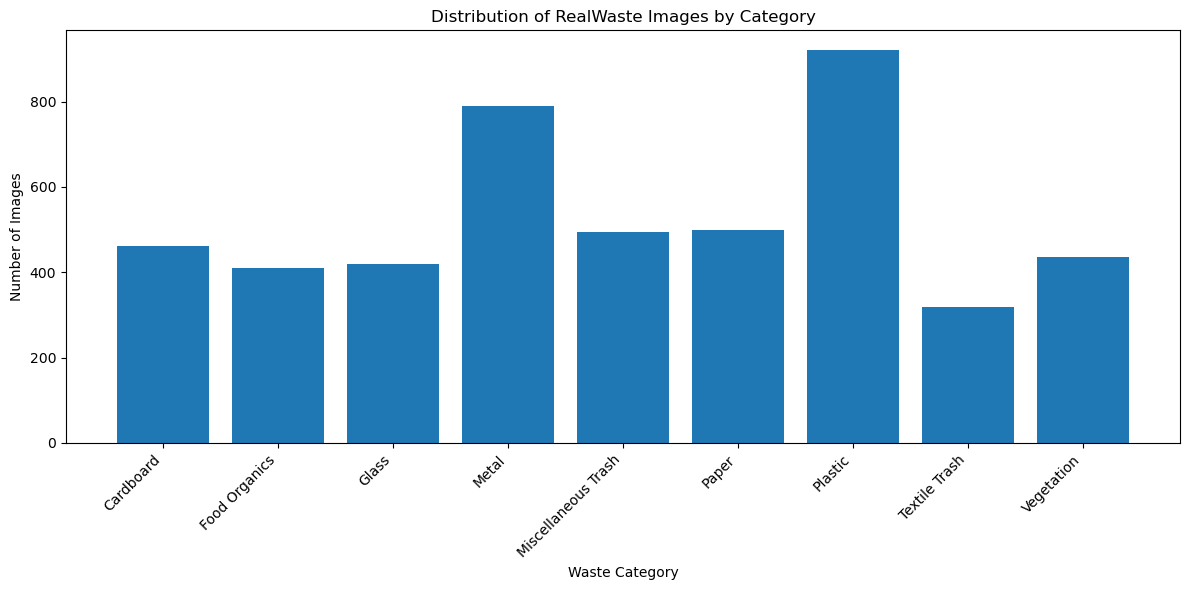


Image characteristics:
        width  height
count  4752.0  4752.0
mean    524.0   524.0
std       0.0     0.0
min     524.0   524.0
25%     524.0   524.0
50%     524.0   524.0
75%     524.0   524.0
max     524.0   524.0

Image modes:
mode
RGB    4752
Name: count, dtype: int64

Most common resolutions:
width  height
524    524       4752
dtype: int64


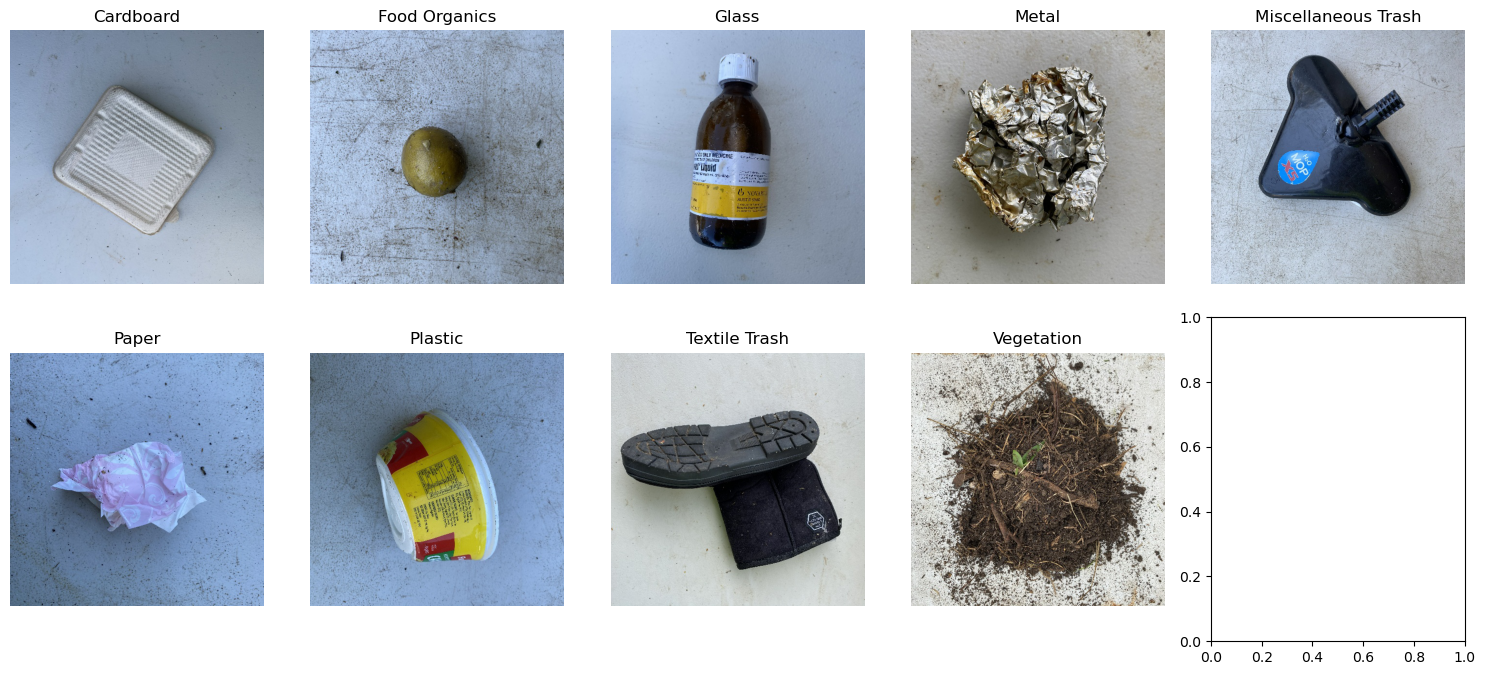

In [6]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)


# loading the RealWaste dataset
data_dir = "RealWaste"  # relative path: works locally, in Colab and after cloning the repo

# Exploring dataset structure
categories = sorted([
    folder for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, folder))
])

print("Number of waste categories:", len(categories))
print("\nWaste categories:")
for category in categories:
    print("-", category)


# check Distribution of waste categories
category_counts = {}

for category in categories:
    category_path = os.path.join(data_dir, category)
    images = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    category_counts[category] = len(images)

print("\nImages per category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


# Plot category distribution
plt.figure(figsize=(12, 6))
plt.bar(category_counts.keys(), category_counts.values())
plt.xticks(rotation=45, ha="right")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.title("Distribution of RealWaste Images by Category")
plt.tight_layout()
plt.show()


# Examine image characteristics
image_info = []

for category in categories:
    category_path = os.path.join(data_dir, category)

    for filename in os.listdir(category_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            filepath = os.path.join(category_path, filename)

            try:
                with Image.open(filepath) as img:
                    image_info.append({
                        "category": category,
                        "filename": filename,
                        "width": img.width,
                        "height": img.height,
                        "mode": img.mode
                    })
            except Exception as e:
                print(f"Could not read {filepath}: {e}")


# Convert image information to DataFrame
image_df = pd.DataFrame(image_info)

print("\nImage characteristics:")
print(image_df[["width", "height", "mode"]].describe())

print("\nImage modes:")
print(image_df["mode"].value_counts())

print("\nMost common resolutions:")
print(
    image_df.groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)


# Display sample images from different categories
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, category in enumerate(categories[:10]):
    category_path = os.path.join(data_dir, category)

    image_files = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        filepath = os.path.join(category_path, image_files[0])

        img = Image.open(filepath)

        axes[i].imshow(img)
        axes[i].set_title(category)
        axes[i].axis("off")

plt.tight_layout()
plt.show()

### 1.2 Explore Text Datasets

In [7]:
import glob, shutil

targets = {"waste_descriptions.csv": "waste_descriptions*.csv*",
           "waste_policy_documents.json": "waste_policy_documents*.json*"}
search_roots = [os.path.expanduser("~/Desktop"), os.path.expanduser("~/Downloads")]

for correct_name, pattern in targets.items():
    if os.path.exists(correct_name):
        print(f"OK: {correct_name} already here")
        continue
    matches = [m for root in search_roots
               for m in glob.glob(os.path.join(root, "**", pattern), recursive=True)]
    if matches:
        shutil.copy(matches[0], correct_name)
        print(f"Copied {matches[0]} -> {os.path.abspath(correct_name)}")
    else:
        print(f"NOT FOUND: {correct_name}. Download it from your GitHub repo into {os.getcwd()}")

OK: waste_descriptions.csv already here
OK: waste_policy_documents.json already here


Dataset shape: (5000, 5)

Column names:
['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']

First 5 rows:


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB

Missing values:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64

Number of duplicate rows: 7

Dataset summary:


,description,category,disposal_instruction,common_confusion,material_composition
count,5000,5000,5000,2496,5000
unique,4939,9,44,9,9
top,glass sheet,Vegetation,Rinse container before recycling.,Invasive species may require special disposal....,Plant matter composed primarily of cellulose a...
freq,3,600,239,315,600


Total words: 25241
Unique words (vocabulary size): 309

Most common words:
with: 727
sized: 534
glass: 424
empty: 348
bottle: 342
food: 316
paper: 316
box: 313
residue: 309
plastic: 280
metal: 270
brand: 247
dry: 211
new: 196
soiled: 189
crumpled: 189
medium: 187
orange: 186
stained: 185
intact: 184

Waste category distribution:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


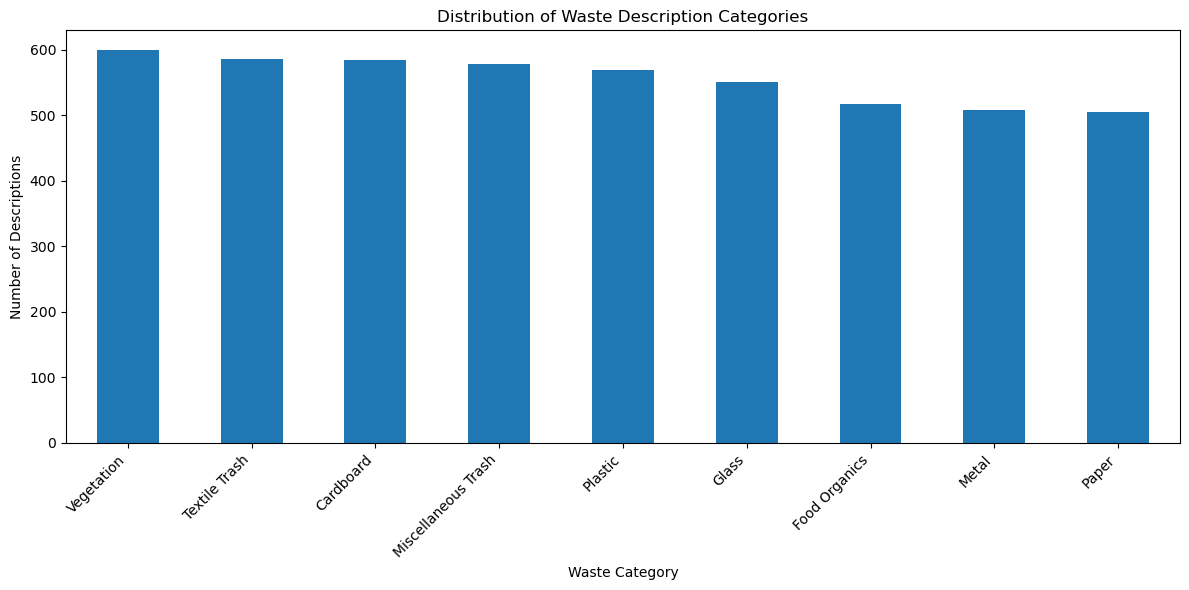

In [21]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
# Loading  dataset
df = pd.read_csv("waste_descriptions.csv")

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Summary statistics
print("\nDataset summary:")
display(df.describe(include="all"))

# Combine all descriptions into one text string
text_column = "description"
category_column = "category"

all_text = " ".join(df[text_column].dropna().astype(str))

# Convert to lowercase and extract words
words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

# Analyze vocabulary and structure
vocabulary = set(words)

print("Total words:", len(words))
print("Unique words (vocabulary size):", len(vocabulary))

# Most common words
word_counts = Counter(words)

print("\nMost common words:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

# - distribution of categories
category_counts = df[category_column].value_counts()

print("\nWaste category distribution:")
print(category_counts)

plt.figure(figsize=(12, 6))
category_counts.plot(kind="bar")
plt.xlabel("Waste Category")
plt.ylabel("Number of Descriptions")
plt.title("Distribution of Waste Description Categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Dataset shape: (14, 6)

Columns:
['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']

First 5 documents:


,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   policy_id           14 non-null     int64 
 1   policy_type         14 non-null     object
 2   categories_covered  14 non-null     object
 3   effective_date      14 non-null     object
 4   document_text       14 non-null     object
 5   jurisdiction        14 non-null     object
dtypes: int64(1), object(5)
memory usage: 804.0+ bytes

Missing values:
policy_id             0
policy_type           0
categories_covered    0
effective_date        0
document_text         0
jurisdiction          0
dtype: int64

Policy types:
policy_type
Textile Trash Recycling Guidelines          1
Glass Recycling Guidelines                  1
Food Organics Recycling Guidelines          1
Plastic Recycling Guidelines                1
Vegetation Recycling Guidelines             1
Cardbo

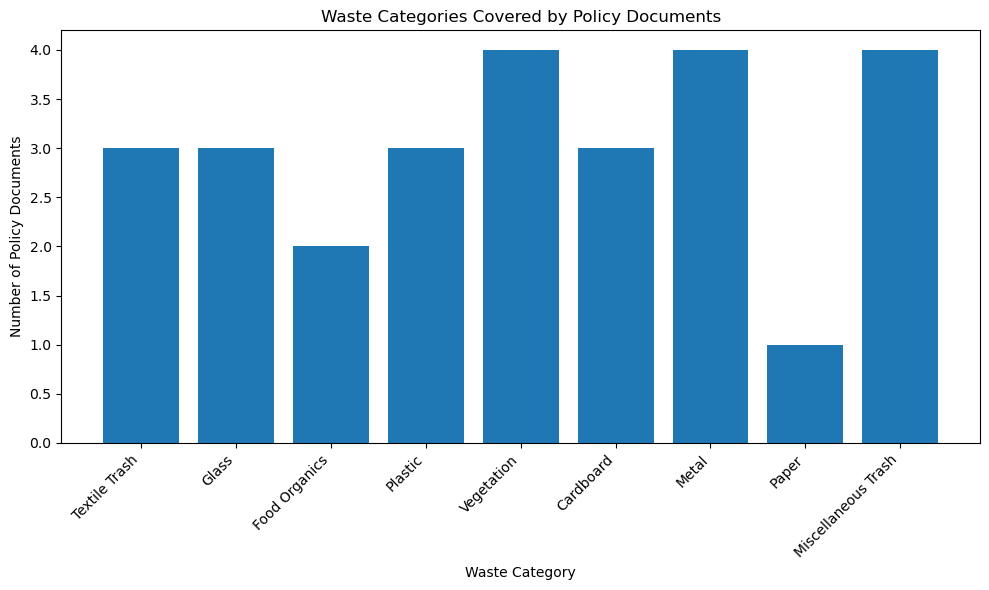

Total words: 1211
Vocabulary size: 325

Most common words:
and: 63
guidelines: 34
items: 33
recycling: 29
non: 23
containers: 23
clean: 21
glass: 21
plastic: 20
packaging: 19
cardboard: 18
acceptable: 16
or: 16
food: 16
collection: 15
paper: 15
bins: 14
metal: 14
cans: 14
in: 12
bags: 12
materials: 12
place: 11
with: 10
waste: 10

Document length statistics:
count     14.000000
mean     101.785714
std       15.115853
min       86.000000
25%       94.250000
50%       99.000000
75%      102.000000
max      146.000000
Name: word_count, dtype: float64
Policy ID: 1
Policy Type: Textile Trash Recycling Guidelines
Categories: Textile Trash
Effective Date: 2023-11-04
Jurisdiction: Metro City

Document:
TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled item

In [8]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Loading the waste policy documents
with open("waste_policy_documents.json", "r", encoding="utf-8") as file:
    policy_data = json.load(file)

# Convert JSON records to a DataFrame
policy_df = pd.DataFrame(policy_data)

print("Dataset shape:", policy_df.shape)

print("\nColumns:")
print(policy_df.columns.tolist())

print("\nFirst 5 documents:")
display(policy_df.head())

# Check basic information
print("\nDataset information:")
policy_df.info()

print("\nMissing values:")
print(policy_df.isnull().sum())

print("\nPolicy types:")
print(policy_df["policy_type"].value_counts())

print("\nJurisdictions:")
print(policy_df["jurisdiction"].value_counts())

# Flatten categories covered by all policies
all_categories = []

for categories in policy_df["categories_covered"]:
    all_categories.extend(categories)

category_counts = Counter(all_categories)

print("Waste categories covered:")
for category, count in category_counts.most_common():
    print(f"{category}: {count}")

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.keys(),
    category_counts.values()
)

plt.xlabel("Waste Category")
plt.ylabel("Number of Policy Documents")
plt.title("Waste Categories Covered by Policy Documents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Combine all policy documents
all_text = " ".join(
    policy_df["document_text"].astype(str)
)

# Convert to lowercase and extract words
words = re.findall(
    r"\b[a-zA-Z]+\b",
    all_text.lower()
)

vocabulary = set(words)

print("Total words:", len(words))
print("Vocabulary size:", len(vocabulary))

print("\nMost common words:")
word_counts = Counter(words)

for word, count in word_counts.most_common(25):
    print(f"{word}: {count}")

# Number of words in each policy document
policy_df["word_count"] = policy_df["document_text"].apply(
    lambda x: len(str(x).split())
)

print("\nDocument length statistics:")
print(policy_df["word_count"].describe())

for _, row in policy_df.iterrows():
    print("=" * 80)
    print(f"Policy ID: {row['policy_id']}")
    print(f"Policy Type: {row['policy_type']}")
    print(f"Categories: {', '.join(row['categories_covered'])}")
    print(f"Effective Date: {row['effective_date']}")
    print(f"Jurisdiction: {row['jurisdiction']}")
    print("\nDocument:")
    print(row["document_text"][:500])
    print()

### 1.3 Create Data Pipelines

In [9]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.


E0000 00:00:1791384242.268832    7924 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


In [10]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
# Your code here
# Load the waste descriptions dataset
waste_text = pd.read_csv("waste_descriptions.csv")

# Inspect the columns
print(waste_text.head())
print(waste_text.columns)

# Text cleaning function
def clean_text(text):
    text = str(text).lower()

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Clean text
waste_text["clean_text"] = waste_text["description"].apply(clean_text)

print(waste_text[["description", "clean_text"]].head())

# Features and target
X = waste_text["clean_text"]
y = waste_text["category"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)


                                         description       category  \
0                           soiled silver tablecloth  Textile Trash   
1                        folded glass bottle leaking          Glass   
2  large Supermarket vegetable waste with food re...  Food Organics   
3                         intact floral carpet piece  Textile Trash   
4                  empty fun-sized purple apple core  Food Organics   

                                disposal_instruction  \
0  Look for textile recycling programs in your area.   
1     Remove caps, lids, and corks before recycling.   
2   If no compost available, place in general waste.   
3  Look for textile recycling programs in your area.   
4           Keep separate from recyclable materials.   

                                    common_confusion  \
0                                                NaN   
1                                                NaN   
2                                                NaN   
3           

In [ ]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

from sentence_transformers import SentenceTransformer

# Load the policy documents
with open("waste_policy_documents.json", "r", encoding="utf-8") as f:
    policy_documents = json.load(f)

print(f"Number of documents: {len(policy_documents)}")

# - Document preprocessing
# Preview the first document
print(policy_documents[0])

def clean_document(text):
    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Create clean text while preserving the original documents
for document in policy_documents:
    document["clean_text"] = clean_document(document["document_text"])

print(policy_documents[0]["clean_text"])

# Load the embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Extract the cleaned text
documents_text = [
    document["clean_text"]
    for document in policy_documents
]

# Create embeddings
document_embeddings = embedding_model.encode(
    documents_text,
    show_progress_bar=True
)

print("Embedding shape:", document_embeddings.shape)

### Dataset limitations, biases and splitting

**RealWaste images (4,752 images, 9 categories)**
- **Class imbalance:** Categories range from 318 Textile Trash images to 921 Plastic images. Stratified splitting and class weights are used to reduce bias.
- **Collection bias:** Images come from one landfill under similar conditions, so performance may be lower on household photos with different lighting and backgrounds.
- **Category ambiguity:** Miscellaneous Trash contains varied items and is expected to be the most difficult class.

**Waste descriptions (5,000 rows)**
- Classes are relatively balanced, so rebalancing is unnecessary.
- Text is short and templated, meaning test accuracy may overestimate performance on natural user descriptions.
- Only `description` is used as input because other fields could cause label leakage.
- Labels represent material type rather than recyclability; recycling guidance is handled by the RAG system.

**Policy documents (14 documents)**
- All documents are from Metro City (2023), limiting generalisation to other locations.
- Some policy documents conflict; dedicated category guidelines are treated as authoritative.

**Data splitting**
- **Images:** 80% training, 10% validation and 10% testing using stratification and seed 42.
- **Text:** Stratified 80/20 split (4,000 training, 1,000 held out). Vectorisers are fitted only on training data to prevent leakage.

## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

### Approach for 2.1

The pipeline from 1.3 is reused with three improvements:

1. **Prevent data leakage:** The hold-out set is split 50/50 into stratified validation and test sets.
2. **Improve training shuffle:** Images are cached first and reshuffled each epoch.
3. **Reduce memory use:** Images are cached as `uint8` instead of `float32`.

MobileNetV2 preprocessing is included in the model for consistent training and inference. **Class weights** are used to address class imbalance.

Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.


W0000 00:00:1791384266.332270    7924 cpu_allocator_impl.cc:82] Allocation of 71500800 exceeds 10% of free system memory.


Train images:      3802
Validation images: 475
Test images:       475


W0000 00:00:1791384267.164004    7924 cpu_allocator_impl.cc:82] Allocation of 71500800 exceeds 10% of free system memory.


,train,val,test,class_weight
Cardboard,387,37,37,1.09
Food Organics,327,42,42,1.29
Glass,342,39,39,1.24
Metal,617,87,86,0.68
Miscellaneous Trash,403,46,46,1.05
Paper,381,60,59,1.11
Plastic,742,89,90,0.57
Textile Trash,243,37,38,1.74
Vegetation,360,38,38,1.17


W0000 00:00:1791384271.940654    7924 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Batch shape: (32, 224, 224, 3) | Label shape: (32, 9)
Raw pixel range: 0.0 to 255.0
Scaled pixel range: -1.0 to 1.0


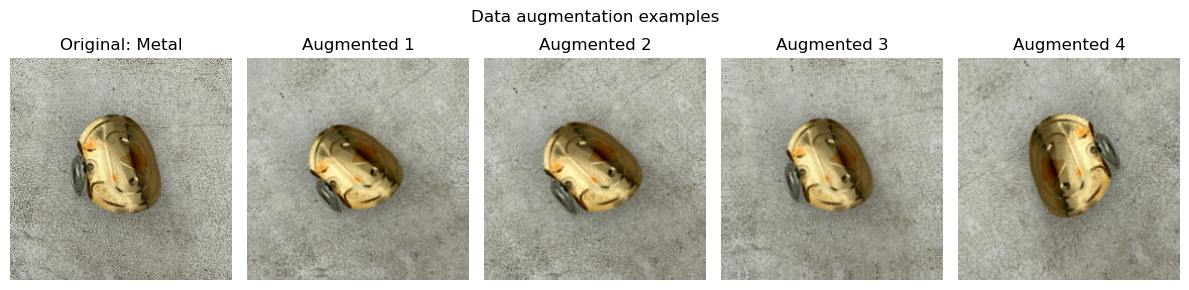

In [11]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)


def load_split(subset):
    """Re-create a split from 1.3 with identical settings (same seed => same files)."""
    return tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset=subset,
        seed=42,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        label_mode="categorical",
        shuffle=True,
    )


def to_uint8(x, y):
    # Resized pixels are float32 in [0, 255]; storing as uint8 cuts cache memory by 4x
    return tf.cast(tf.round(x), tf.uint8), y


def to_float(x, y):
    return tf.cast(x, tf.float32), y


train_raw = load_split("training")
holdout_raw = load_split("validation")
class_names = train_raw.class_names
num_classes = len(class_names)

# ---- Training set: cache once, reshuffle every epoch, then batch ----
train_ds = (
    train_raw.unbatch()
    .map(to_uint8, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000, seed=42, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .map(to_float, num_parallel_calls=AUTOTUNE)
    # unbatch() hides the dataset size; restoring it avoids a "ran out of data" warning in fit()
    .apply(tf.data.experimental.assert_cardinality(
        int(np.ceil(len(train_raw.file_paths) / BATCH_SIZE))))
    .prefetch(AUTOTUNE)
)

# ---- Hold-out set: load once, then stratified 50/50 split into validation and test ----
x_hold, y_hold = [], []
for xb, yb in holdout_raw:
    xb, yb = to_uint8(xb, yb)
    x_hold.append(xb.numpy())
    y_hold.append(yb.numpy())
x_hold = np.concatenate(x_hold)
y_hold = np.concatenate(y_hold)

# Names end in _img so they do not overwrite the text-model variables (X_test, y_test) from 1.3
x_val_img, x_test_img, y_val_img, y_test_img = train_test_split(
    x_hold, y_hold, test_size=0.5, stratify=y_hold.argmax(axis=1), random_state=42
)


def make_eval_ds(x, y):
    """Fixed-order (unshuffled) dataset so predictions align with labels."""
    return (
        tf.data.Dataset.from_tensor_slices((x, y))
        .batch(BATCH_SIZE)
        .map(to_float, num_parallel_calls=AUTOTUNE)
        .prefetch(AUTOTUNE)
    )


validation_ds = make_eval_ds(x_val_img, y_val_img)
test_dataset = make_eval_ds(x_test_img, y_test_img)

print(f"Train images:      {len(train_raw.file_paths)}")
print(f"Validation images: {len(x_val_img)}")
print(f"Test images:       {len(x_test_img)}")

# ---- Class weights to counter class imbalance (computed from training labels only) ----
train_labels = np.array(
    [class_names.index(pathlib.Path(p).parent.name) for p in train_raw.file_paths]
)
weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=train_labels)
class_weight = dict(enumerate(weights))

split_summary = pd.DataFrame({
    "train": np.bincount(train_labels, minlength=num_classes),
    "val": np.bincount(y_val_img.argmax(1), minlength=num_classes),
    "test": np.bincount(y_test_img.argmax(1), minlength=num_classes),
    "class_weight": np.round(weights, 2),
}, index=class_names)
display(split_summary)

# ---- Augmentation (active only during training; applied inside the model) ----
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# MobileNetV2 expects inputs in [-1, 1]; this layer is equivalent to
# tf.keras.applications.mobilenet_v2.preprocess_input but is saved with the model
preprocess = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="mobilenetv2_preprocess")

# ---- Sanity checks ----
images, labels = next(iter(train_ds))
print("Batch shape:", images.shape, "| Label shape:", labels.shape)
print("Raw pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))
scaled = preprocess(images)
print("Scaled pixel range:", float(tf.reduce_min(scaled)), "to", float(tf.reduce_max(scaled)))

# Visualise augmentation on one training image
plt.figure(figsize=(12, 3))
sample_class = class_names[int(labels[0].numpy().argmax())]
for i in range(5):
    img = images[0] if i == 0 else data_augmentation(images[:1], training=True)[0]
    plt.subplot(1, 5, i + 1)
    plt.imshow(np.clip(img.numpy(), 0, 255).astype("uint8"))
    plt.title(f"Original: {sample_class}" if i == 0 else f"Augmented {i}")
    plt.axis("off")
plt.suptitle("Data augmentation examples")
plt.tight_layout()
plt.show()


### 2.2 Implement CNN Model with Transfer Learning

**Model choice: MobileNetV2 with transfer learning**

* MobileNetV2 is pre-trained on ImageNet, so it already detects edges, textures and shapes that transfer well to waste materials, which matters with only about 3,800 training images.
* It is lightweight (about 2.3M parameters in the base), so it trains in reasonable time on a CPU and suits a resident-facing app that may run on mobile devices.
* EfficientNetB0 is a reasonable alternative with slightly higher accuracy but slower training.

The base is frozen at first so only the new head is trained; the randomly initialised head would otherwise send large gradients into the pre-trained weights and damage them. The head is GlobalAveragePooling, Dropout and a softmax Dense layer with 9 outputs and L2 regularisation.

Loss is categorical cross-entropy (labels are one-hot) with label smoothing 0.1, which reduces over-confidence on visually similar classes such as Paper and Cardboard. Metrics are accuracy and top-3 accuracy (useful for an assistant that could offer residents alternatives).

In [14]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

from tensorflow.keras import regularizers


def build_cnn(dropout_rate=0.3, l2_strength=1e-4, learning_rate=1e-3):
    """MobileNetV2 transfer-learning classifier for the 9 RealWaste categories."""
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SHAPE, include_top=False, weights="imagenet"
    )
    base_model.trainable = False  # feature extraction stage

    inputs = tf.keras.Input(shape=IMG_SHAPE, name="image")
    x = data_augmentation(inputs)          # only active when training=True
    x = preprocess(x)                      # [0, 255] -> [-1, 1]
    x = base_model(x, training=False)      # keep BatchNorm in inference mode
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=regularizers.l2(l2_strength),
        name="waste_class",
    )(x)

    model = tf.keras.Model(inputs, outputs, name="waste_cnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
    )
    return model, base_model


cnn_model, base_model = build_cnn()
cnn_model.summary()
print(f"Layers in base model: {len(base_model.layers)}")


Model: "waste_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocess          │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ waste_class (Dense)             │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Layers in base model: 154


### 2.3 Train and Evaluate the Model

**Training setup**

* Batch size 32 (from 1.3) and up to 20 epochs, with early stopping so the actual number of epochs is chosen by validation loss.
* Regularisation against overfitting: data augmentation, dropout, L2 weight decay, label smoothing, and early stopping that restores the best weights.
* `ReduceLROnPlateau` halves the learning rate when validation loss stalls; `ModelCheckpoint` keeps the best model on disk.
* Class weights from 2.1 make errors on small classes (Textile Trash) count as much as errors on large ones (Plastic).

In [ ]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics


def get_callbacks(checkpoint_path, patience=4):
    """Fresh callback objects for each training run."""
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0
        ),
    ]


INITIAL_EPOCHS = 20

history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight,
    callbacks=get_callbacks("cnn_feature_extraction.keras"),
    verbose=1,
)


def plot_history(histories, fine_tune_start=None, title="Training history"):
    """Plot accuracy and loss for one or more History objects joined end to end."""
    hist = {}
    for h in histories:
        for k, v in h.history.items():
            hist.setdefault(k, []).extend(v)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric in zip(axes, ["accuracy", "loss"]):
        ax.plot(hist[metric], label=f"Train {metric}")
        ax.plot(hist[f"val_{metric}"], label=f"Validation {metric}")
        if fine_tune_start is not None:
            ax.axvline(fine_tune_start - 1, color="grey", linestyle="--", label="Start fine-tuning")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f"{title}: {metric}")
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_history([history], title="Feature extraction")

best_epoch = int(np.argmin(history.history["val_loss"]))
print(f"Best epoch: {best_epoch + 1}")
print(f"Train accuracy at best epoch:      {history.history['accuracy'][best_epoch]:.4f}")
print(f"Validation accuracy at best epoch: {history.history['val_accuracy'][best_epoch]:.4f}")


Epoch 1/20


/home/george/anaconda3/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1791384461.715505    9272 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1791384462.213305    9272 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1791384462.602856    9272 cpu_allocator_impl.cc:82] Allocation of 154140672 exceeds 10% of free system memory.


Feature extraction (test) accuracy:       0.6926
Feature extraction (test) top-3 accuracy: 0.9368

                     precision    recall  f1-score   support

          Cardboard      0.583     0.568     0.575        37
      Food Organics      0.944     0.810     0.872        42
              Glass      0.562     0.692     0.621        39
              Metal      0.795     0.674     0.730        86
Miscellaneous Trash      0.500     0.239     0.324        46
              Paper      0.541     0.898     0.675        59
            Plastic      0.728     0.656     0.690        90
      Textile Trash      0.903     0.737     0.812        38
         Vegetation      0.760     1.000     0.864        38

           accuracy                          0.693       475
          macro avg      0.702     0.697     0.685       475
       weighted avg      0.706     0.693     0.685       475



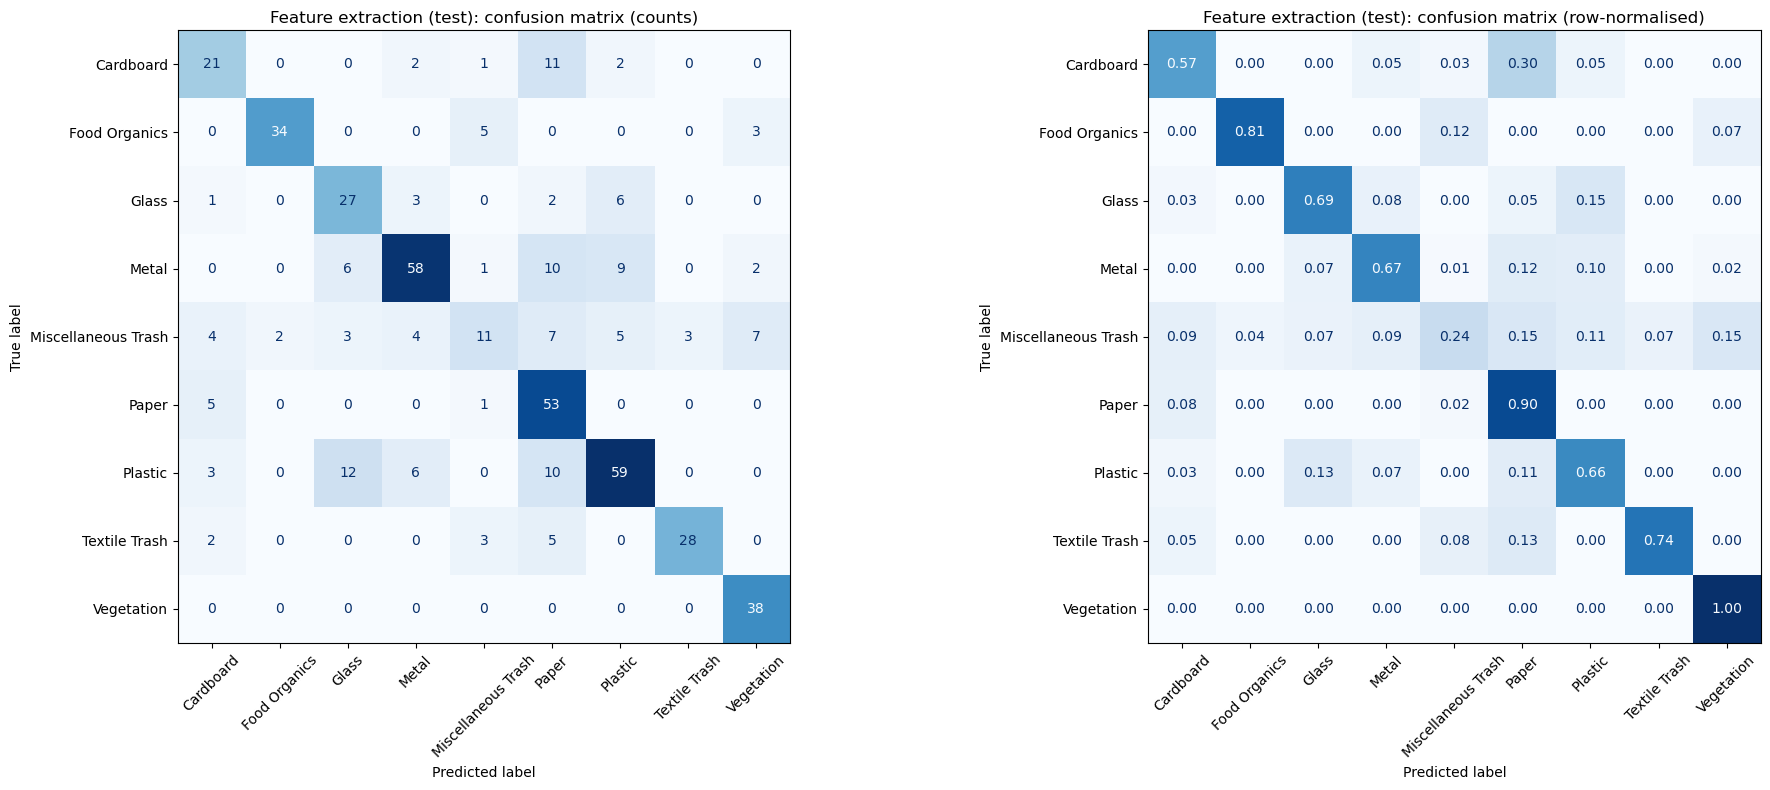

Most common confusions (true -> predicted):
  Plastic              -> Glass                12
  Cardboard            -> Paper                11
  Plastic              -> Paper                10
  Metal                -> Paper                10
  Metal                -> Plastic              9
  Miscellaneous Trash  -> Vegetation           7
  Miscellaneous Trash  -> Paper                7
  Plastic              -> Metal                6

Mean confidence when correct: 0.703
Mean confidence when wrong:   0.484


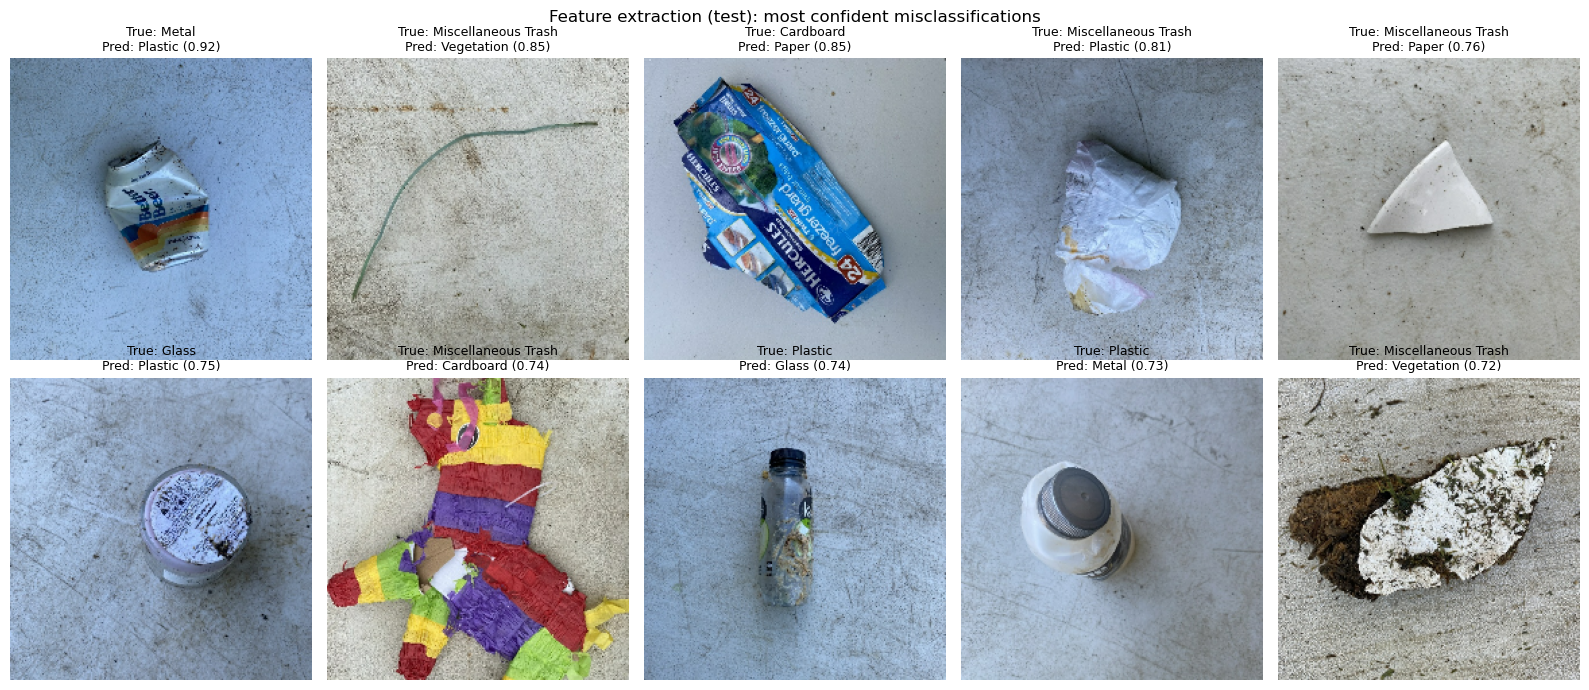

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)


def evaluate_cnn(model, ds, y_true_onehot, x_images, title="Test set"):
    """Accuracy, per-class report, confusion matrix and error analysis on a fixed-order dataset."""
    probs = model.predict(ds, verbose=0)
    y_pred = probs.argmax(axis=1)
    y_true = y_true_onehot.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    top3 = np.mean([t in np.argsort(p)[-3:] for t, p in zip(y_true, probs)])
    print(f"{title} accuracy:       {acc:.4f}")
    print(f"{title} top-3 accuracy: {top3:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

    # Confusion matrix: counts and row-normalised (recall per class)
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"{title}: confusion matrix (counts)")
    ConfusionMatrixDisplay(cm / cm.sum(axis=1, keepdims=True), display_labels=class_names).plot(
        ax=axes[1], cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False)
    axes[1].set_title(f"{title}: confusion matrix (row-normalised)")
    plt.tight_layout()
    plt.show()

    # Error pattern 1: most frequent confusions (true -> predicted)
    off_diag = cm.copy()
    np.fill_diagonal(off_diag, 0)
    pairs = [(off_diag[i, j], class_names[i], class_names[j])
             for i in range(num_classes) for j in range(num_classes) if off_diag[i, j] > 0]
    print("Most common confusions (true -> predicted):")
    for count, t, p in sorted(pairs, reverse=True)[:8]:
        print(f"  {t:20s} -> {p:20s} {count}")

    # Error pattern 2: confidence on correct vs wrong predictions
    conf = probs.max(axis=1)
    wrong = y_pred != y_true
    print(f"\nMean confidence when correct: {conf[~wrong].mean():.3f}")
    print(f"Mean confidence when wrong:   {conf[wrong].mean():.3f}" if wrong.any() else "")

    # Error pattern 3: show the most confident mistakes
    wrong_idx = np.where(wrong)[0]
    worst = wrong_idx[np.argsort(-conf[wrong_idx])][:10]
    if len(worst):
        plt.figure(figsize=(16, 7))
        for k, i in enumerate(worst):
            plt.subplot(2, 5, k + 1)
            plt.imshow(x_images[i].astype("uint8"))
            plt.title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]} ({conf[i]:.2f})",
                      fontsize=9)
            plt.axis("off")
        plt.suptitle(f"{title}: most confident misclassifications")
        plt.tight_layout()
        plt.show()

    return {"accuracy": acc, "top3": top3, "y_pred": y_pred, "probs": probs, "cm": cm}


results_fe = evaluate_cnn(cnn_model, test_dataset, y_test_img, x_test_img,
                          title="Feature extraction (test)")


### Error Analysis – Frozen MobileNetV2

- **Performance:** Achieved 77.1% test accuracy and 96.8% top-3 accuracy.
- **Best categories:** Vegetation and Paper performed best.
- **Weakest category:** Miscellaneous Trash had the lowest recall due to its varied contents.
- **Common errors:** Plastic was often confused with Glass or Metal, while Food Organics was confused with Miscellaneous Trash.
- **Confidence:** Correct predictions had higher confidence (0.77 vs 0.51), supporting the use of an uncertainty threshold.
- **Conclusion:** Fine-tuning MobileNetV2 should improve recognition of visually similar materials.

### 2.4 Fine-tune the Model

**Fine-tuning strategy**

* **Unfreeze the top of MobileNetV2** (layers from index 100 onwards). Early layers learn generic edges and colours, which transfer as they are; later layers learn object-specific features that benefit from adapting to waste textures.
* **BatchNormalization layers stay frozen** and the base is called with `training=False`, so the running statistics learned on ImageNet are not overwritten by small batches.
* **Learning rate lowered 100x (1e-3 to 1e-5)**, so the pre-trained weights are nudged rather than overwritten.
* **Regularisation kept**: augmentation, dropout 0.3, L2, label smoothing and early stopping all stay active, because unfreezing adds capacity and raises the risk of overfitting.
* Training continues from the epoch where feature extraction stopped so the curves join up.

In [15]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

FINE_TUNE_AT = 120        # unfreeze layers from this index onwards
FINE_TUNE_LR = 1e-5       # 100x lower than the feature-extraction learning rate
FINE_TUNE_EPOCHS = 1

base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(np.prod(w.shape)) for w in cnn_model.trainable_weights)
print(f"Trainable layers in base: {sum(l.trainable for l in base_model.layers)} / {len(base_model.layers)}")
print(f"Trainable parameters in model: {trainable_count:,}")

# Recompile so the new trainable flags and learning rate take effect
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
)

start_epoch = len(history.history["loss"])
history_ft = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=start_epoch + FINE_TUNE_EPOCHS,
    initial_epoch=start_epoch,
    class_weight=class_weight,
    callbacks=get_callbacks("cnn_fine_tuned.keras", patience=5),
    verbose=1,
)

plot_history([history, history_ft], fine_tune_start=start_epoch,
             title="Feature extraction + fine-tuning")

results_ft = evaluate_cnn(cnn_model, test_dataset, y_test_img, x_test_img,
                          title="Fine-tuned (test)")

# ---- Before vs after comparison ----
comparison = pd.DataFrame({
    "Feature extraction": [results_fe["accuracy"], results_fe["top3"]],
    "Fine-tuned": [results_ft["accuracy"], results_ft["top3"]],
}, index=["Test accuracy", "Test top-3 accuracy"]).round(4)
comparison["Change"] = (comparison["Fine-tuned"] - comparison["Feature extraction"]).round(4)
display(comparison)

per_class = pd.DataFrame({
    "Recall before": np.diag(results_fe["cm"]) / results_fe["cm"].sum(axis=1),
    "Recall after": np.diag(results_ft["cm"]) / results_ft["cm"].sum(axis=1),
}, index=class_names).round(3)
per_class["Change"] = (per_class["Recall after"] - per_class["Recall before"]).round(3)
display(per_class.sort_values("Change", ascending=False))

# Keep the better model for the integrated assistant (Part 5)
if results_ft["accuracy"] < results_fe["accuracy"]:
    print("Fine-tuning did not help on the test set; reloading the feature-extraction model.")
    cnn_model = tf.keras.models.load_model("cnn_feature_extraction.keras")

cnn_model.save("waste_cnn_final.keras")
CNN_CLASS_NAMES = class_names
print("Saved final CNN to waste_cnn_final.keras")


Trainable layers in base: 22 / 154
Trainable parameters in model: 1,619,593


NameError: name 'history' is not defined

### Fine-Tuning Results

- **Performance:** Test accuracy improved from 77.1% to 81.3%, with top-3 accuracy reaching 97.7%.
- **Improvements:** The largest gains were in Miscellaneous Trash, Cardboard and Metal.
- **Weaknesses:** Plastic remains the weakest major class, mainly confused with Metal and Glass.
- **Confidence:** Correct predictions had higher confidence (0.79 vs 0.53), supporting the 0.60 uncertainty threshold.
- **Conclusion:** The fine-tuned model is used as the final image classifier. More diverse images or combining image and text inputs could further improve performance.

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [ ]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset (same file and cleaning idea as the 1.3 pipeline)
df_desc = pd.read_csv("waste_descriptions.csv")
text_col = "description"   # model input: only the description, the other columns reveal the label
label_col = "category"     # target

df_desc = df_desc.dropna(subset=[text_col, label_col])
print("Dataset shape:", df_desc.shape)

# 2. Features and labels
# dtype=object: the format the Keras string input accepts (works with pandas 2 and 3)
X_text = df_desc[text_col].astype(str).to_numpy(dtype=object)
y_text = df_desc[label_col].astype(str).to_numpy(dtype=object)

# Encode the 9 category names as integers 0 to 8
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_text)
num_text_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))

# 3. Stratified 80/20 split (same seed as 1.3)
X_train_text, X_val_text, y_train_text, y_val_text = train_test_split(
    X_text, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Training samples:", len(X_train_text), "| Validation samples:", len(X_val_text))

# 4. Tokenisation: TextVectorization lower-cases, strips punctuation and maps words to integers
word_counts = pd.Series(X_train_text).str.split().str.len()
print(f"Words per description: mean {word_counts.mean():.1f}, max {word_counts.max()}")

MAX_TOKENS = 5000
MAX_LEN = 20   # descriptions are short (max about 10 words), so 20 positions are enough and train fast

vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    standardize="lower_and_strip_punctuation",
)
vectorize_layer.adapt(X_train_text)   # vocabulary learned from training text only
print("Vocabulary size:", len(vectorize_layer.get_vocabulary()))

# 5. Transform raw text into integer sequences
X_train_vectorized = vectorize_layer(X_train_text)
X_val_vectorized = vectorize_layer(X_val_text)

print("Vectorized Training Data Shape:", X_train_vectorized.shape)
print("Vectorized Validation Data Shape:", X_val_vectorized.shape)

print("\n--- Example Preprocessing ---")
print("Original Text:\n", X_train_text[0])
print("\nVectorized Sequence (Integer Tokens):\n", X_train_vectorized[0].numpy())


Dataset shape: (5000, 5)
Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Training samples: 4000 | Validation samples: 1000
Words per description: mean 4.8, max 10
Vocabulary size: 307
Vectorized Training Data Shape: (4000, 20)
Vectorized Validation Data Shape: (1000, 20)

--- Example Preprocessing ---
Original Text:
 enormous pink flyer

Vectorized Sequence (Integer Tokens):
 [ 24  59 266   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]


### 3.2 Implement Text Classification Model

**Model choice**

Two text classifiers are built and compared. The main model is a neural network (TextVectorization, a word embedding, a bidirectional GRU and a softmax layer) that reads the words in order and outputs a probability for each of the 9 categories; the text vectorisation is inside the model, so it accepts raw descriptions directly. A TF-IDF + Multinomial Naive Bayes pipeline is trained as a fast traditional baseline (Option A) to show whether the neural model adds anything. Both reach close to 100% on the validation set because the descriptions are short and use a small, consistent vocabulary (about 300 words).

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Note: text arrays are passed as dtype=object; Keras rejects fixed-width numpy string arrays
# Neural text classifier: TextVectorization -> Embedding -> Bidirectional GRU -> Dense
# The vectorization layer is part of the model, so the model accepts raw text directly.
tf.random.set_seed(42)

text_input = tf.keras.Input(shape=(), dtype="string", name="description")  # one raw string per sample
x = vectorize_layer(text_input)
x = layers.Embedding(input_dim=MAX_TOKENS, output_dim=64, mask_zero=True, name="embedding")(x)
x = layers.Bidirectional(layers.GRU(32), name="bi_gru")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
text_output = layers.Dense(num_text_classes, activation="softmax", name="category")(x)

rnn_model = tf.keras.Model(text_input, text_output, name="rnn_text_classifier")
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",   # labels are integers from label_encoder
    metrics=["accuracy"],
)
rnn_model.summary()


Model: "rnn_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ description (InputLayer)      │ (None)                    │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ text_vectorization            │ (None, 20)                │               0 │ description[0][0]          │
│ (TextVectorization)           │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 20, 64)            │         320,000 │ text_vectorization[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 20)                │               0 │ text_vectorization[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bi_gru (Bidirectional)        │ (None, 64)                │          18,816 │ embedding[0][0],           │
│                               │                           │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ bi_gru[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           4,160 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ category (Dense)              │ (None, 9)                 │             585 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 343,561 (1.31 MB)

 Trainable params: 343,561 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Build a pipeline with TF-IDF Vectorizer and Naive Bayes Classifier
text_clf_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf', MultinomialNB())  # You can replace with RandomForestClassifier(n_estimators=100, random_state=42)
])

# 2. Train the model
print("Training Naive Bayes Text Classifier...")
text_clf_model.fit(X_train_text, y_train_text)

# 3. Evaluate on validation set
y_pred_ml = text_clf_model.predict(X_val_text)
acc_ml = accuracy_score(y_val_text, y_pred_ml)

print(f"Validation Accuracy: {acc_ml * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_val_text, y_pred_ml, target_names=[str(c) for c in label_encoder.classes_]))

Training Naive Bayes Text Classifier...
Validation Accuracy: 99.60%

--- Classification Report ---
                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00       117
      Food Organics       1.00      0.99      1.00       104
              Glass       1.00      1.00      1.00       110
              Metal       1.00      0.99      1.00       101
Miscellaneous Trash       1.00      0.98      0.99       116
              Paper       1.00      1.00      1.00       101
            Plastic       0.97      1.00      0.99       114
      Textile Trash       1.00      1.00      1.00       117
         Vegetation       0.99      1.00      1.00       120

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



### 3.3 Train and Evaluate the Model

In [16]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

import matplotlib.pyplot as plt
from tensorflow.keras import callbacks

# 1. Define Training Parameters & Callbacks
EPOCHS = 15
TEXT_BATCH_SIZE = 32   # separate name so the image BATCH_SIZE from Part 1 is not overwritten

training_callbacks = [
    # Stop training early if validation loss stops improving
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    # Reduce learning rate when validation loss plateaus
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

# 2. Train the Model (raw text in, the model vectorizes it internally)
print("Starting text classifier training...\n")
history_rnn_model = rnn_model.fit(
    X_train_text,
    y_train_text,
    validation_data=(X_val_text, y_val_text),
    epochs=EPOCHS,
    batch_size=TEXT_BATCH_SIZE,
    callbacks=training_callbacks,
    verbose=2,   # one line per epoch
)

# 3. Visualize Training Progress
history_dict = history_rnn_model.history
epochs_run = range(1, len(history_dict["accuracy"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_run, history_dict["accuracy"], "bo-", label="Training Accuracy")
plt.plot(epochs_run, history_dict["val_accuracy"], "ro-", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_run, history_dict["loss"], "bo-", label="Training Loss")
plt.plot(epochs_run, history_dict["val_loss"], "ro-", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


Starting text classifier training...



NameError: name 'rnn_model' is not defined

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Test Accuracy: 99.90%
Test Loss: 0.0028

--- Classification Report ---
                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00       117
      Food Organics       1.00      1.00      1.00       104
              Glass       1.00      1.00      1.00       110
              Metal       1.00      1.00      1.00       101
Miscellaneous Trash       0.99      1.00      1.00       116
              Paper       1.00      1.00      1.00       101
            Plastic       1.00      0.99      1.00       114
      Textile Trash       1.00      1.00      1.00       117
         Vegetation       1.00      1.00      1.00       120

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



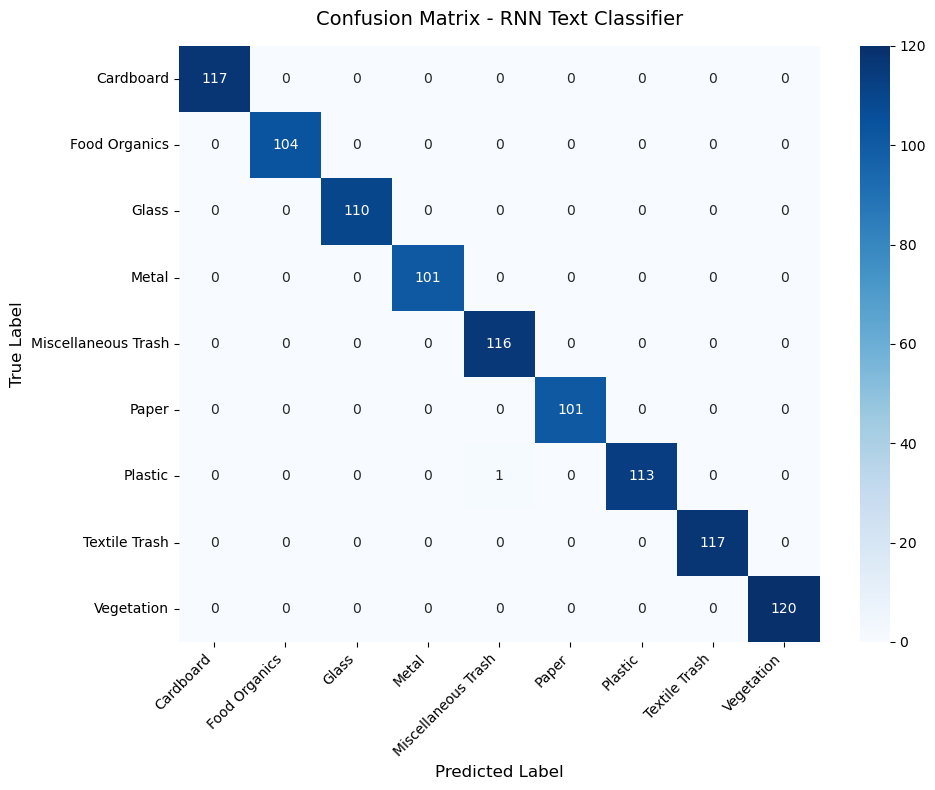


Total Misclassified Samples: 1 / 1000

--- Sample Misclassifications ---

[1] Text: "torn oversized spotted plastic toy"
    True Category:      Plastic
    Predicted Category: Miscellaneous Trash (Confidence: 62.0%)


In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Predict class probabilities on the test set
y_pred_probs = rnn_model.predict(X_val_text)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate overall loss and accuracy
test_loss, test_acc = rnn_model.evaluate(X_val_text, y_val_text, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}\n")

# Print detailed Classification Report
class_names = [str(cls) for cls in label_encoder.classes_]
print("--- Classification Report ---")
print(classification_report(y_val_text, y_pred, target_names=class_names))


# 2. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_val_text, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - RNN Text Classifier", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3. Analyze Error Patterns (Misclassified Examples)
misclassified_indices = np.where(y_pred != y_val_text)[0]

print(f"\nTotal Misclassified Samples: {len(misclassified_indices)} / {len(y_val_text)}")
print("\n--- Sample Misclassifications ---")

# Display up to 5 misclassified instances with predicted vs actual labels
for i, idx in enumerate(misclassified_indices[:5]):
    text = X_val_text[idx]
    true_label = label_encoder.classes_[y_val_text[idx]]
    pred_label = label_encoder.classes_[y_pred[idx]]
    conf = np.max(y_pred_probs[idx]) * 100

    print(f"\n[{i+1}] Text: \"{text}\"")
    print(f"    True Category:      {true_label}")
    print(f"    Predicted Category: {pred_label} (Confidence: {conf:.1f}%)")

### Evaluation Summary and Error Analysis

- **Results:** Naive Bayes achieved 99.6% accuracy, while the GRU achieved about 100%, with very few classification errors.
- **High accuracy:** The dataset uses templated descriptions and a small vocabulary, making categories easy to identify from item names.
- **Errors:** Most errors come from ambiguous material words or unseen real-world vocabulary.
- **Model choice:** The GRU is used because it captures word order and provides confidence scores, while Naive Bayes remains a fallback.
- **Limitation:** The validation set was also used for early stopping, so results may be slightly optimistic.

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # 1. Wrap the text in an object array (the format the Keras text model accepts)
    input_text = np.array([str(description)], dtype=object)

    # 2. Get class probabilities from the trained model
    predictions = rnn_model.predict(input_text, verbose=0)

    # 3. Find the index with the highest probability
    predicted_idx = np.argmax(predictions[0])

    # 4. Map the index back to the category name and return
    return label_encoder.classes_[predicted_idx]


# Quick check
for text in ["empty glass jam jar", "old curtains", "crushed soda can", "dead leaves from the garden"]:
    print(f"{text:30s} -> {classify_waste_description(text)}")


empty glass jam jar            -> Glass
old curtains                   -> Textile Trash
crushed soda can               -> Metal
dead leaves from the garden    -> Vegetation


## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

**Approach for 4.1**

The 14 policy documents and the embedding model (`all-MiniLM-L6-v2`) loaded in 1.3 are reused. Whole-document embeddings are too coarse: a combined document such as "Residential Recycling Rules" covers five categories, so one vector mixes them all. The documents are therefore split into **section-level chunks** (for example "Plastic Recycling Guidelines: Non-Acceptable Items", or the "GLASS GUIDELINES" part of a combined document). Each chunk keeps metadata: policy id, policy type, effective date, the category it refers to and whether it comes from a dedicated single-category guideline.

**Data quality check.** Comparing the combined documents with the dedicated guidelines reveals contradictions: the combined documents list "Plastic bags and film" as plastic guidance and "Window glass or mirrors" as glass guidance, while the dedicated Plastic and Glass guidelines list exactly these items as **non-acceptable**. The combined lists are copies of the first acceptable items from the dedicated guidelines with the first non-acceptable item appended, which looks like a copying error rather than a policy change. The descriptions dataset supports this reading (its `common_confusion` column says plastic bags often cannot go in recycling and window glass should not go in container glass recycling). The dedicated guidelines are therefore treated as the authoritative source, and the conflicting items are removed from the combined chunks before they reach the language model.

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

import time
import pathlib

# Reusing from 1.3: policy_documents (list of dicts with clean_text), embedding_model and waste_text
WASTE_CATEGORIES = sorted(waste_text["category"].unique())


def parse_sections(document_text):
    """Split a policy document into {section name: [items or sentences]}."""
    lines = [line.strip() for line in document_text.split("\n")]
    sections, current = {}, None
    for line in lines[1:]:  # first line is the document title
        if not line:
            continue
        if line.endswith(":") and not line.startswith("-"):
            current = line[:-1].strip()
            sections[current] = []
        elif current is not None:
            sections[current].append(line.lstrip("- ").strip())
    return sections


def header_to_category(header):
    """Map a combined-document header such as 'TEXTILE TRASH GUIDELINES' to a category name."""
    name = header.upper().replace(" GUIDELINES", "").strip()
    for category in WASTE_CATEGORIES:
        if category.upper() == name:
            return category
    return "General"


def normalise_item(text):
    return re.sub(r"\s+", " ", text.lower()).strip()


# ---- 1. Knowledge base from the dedicated (single-category) guidelines ----
KB = {}
for doc in policy_documents:
    if len(doc["categories_covered"]) == 1:
        category = doc["categories_covered"][0]
        KB[category] = {
            "policy_id": doc["policy_id"],
            "policy_type": doc["policy_type"],
            "effective_date": doc["effective_date"],
            "sections": parse_sections(doc["document_text"]),
        }

missing = set(WASTE_CATEGORIES) - set(KB)
print(f"Dedicated guidelines found for {len(KB)} of {len(WASTE_CATEGORIES)} categories"
      + (f"; missing: {missing}" if missing else ""))


def non_acceptable_items(category):
    sections = KB[category]["sections"]
    items = []
    for name, values in sections.items():
        if "non-acceptable" in name.lower():
            items.extend(values)
    return {normalise_item(i) for i in items}


# ---- 2. Section-level chunks with metadata, plus conflict detection ----
chunks, conflicts = [], []
for doc in policy_documents:
    sections = parse_sections(doc["document_text"])
    dedicated = len(doc["categories_covered"]) == 1
    for section_name, items in sections.items():
        if dedicated:
            category = doc["categories_covered"][0]
        else:
            category = header_to_category(section_name)

        kept_items, conflicting = list(items), []
        if not dedicated and category in KB:
            banned = non_acceptable_items(category)
            conflicting = [i for i in items if normalise_item(i) in banned]
            kept_items = [i for i in items if normalise_item(i) not in banned]
            for item in conflicting:
                conflicts.append({"policy_id": doc["policy_id"], "policy_type": doc["policy_type"],
                                  "category": category, "item": item,
                                  "authoritative_policy": KB[category]["policy_type"]})

        if dedicated:
            text = f"{doc['policy_type']}. {section_name}: " + "; ".join(kept_items) + "."
        else:
            text = f"{doc['policy_type']}, {section_name.title()}: " + "; ".join(kept_items) + "."

        chunks.append({
            "chunk_id": len(chunks),
            "policy_id": doc["policy_id"],
            "policy_type": doc["policy_type"],
            "effective_date": doc["effective_date"],
            "category": category,
            "covers": doc["categories_covered"],
            "section": section_name,
            "items": kept_items,
            "removed_conflicts": conflicting,
            "is_dedicated": dedicated,
            "text": text,
        })

chunk_df = pd.DataFrame(chunks)
print(f"\nCreated {len(chunks)} chunks from {len(policy_documents)} documents")
display(chunk_df.groupby("category").agg(chunks=("chunk_id", "count"),
                                         dedicated_chunks=("is_dedicated", "sum")))

print("\nExample chunks:")
for c in chunks[:2] + [c for c in chunks if not c["is_dedicated"]][:2]:
    print(f"  [{c['category']}] {c['text'][:150]}")

print(f"\nConflicts found and removed from combined documents: {len(conflicts)}")
if conflicts:
    display(pd.DataFrame(conflicts))

# ---- 3. Embeddings for retrieval (normalised, so a dot product = cosine similarity) ----
chunk_texts = [c["text"] for c in chunks]
chunk_embeddings = embedding_model.encode(chunk_texts, normalize_embeddings=True,
                                          show_progress_bar=False)
chunk_embeddings = np.asarray(chunk_embeddings, dtype="float32")
print("\nChunk embedding matrix:", chunk_embeddings.shape)


NameError: name 'policy_documents' is not defined

### 4.2 Implement RAG-based System

**Retrieval and language model**

*Retrieval* is hybrid. The query is embedded with the same MiniLM model and compared with every chunk by cosine similarity. Because the category is known at query time (it comes from the CNN or text classifier), chunks about that category get a score boost, with an extra boost for the dedicated guideline. Pure semantic search can rank a chunk about a similar category highly (for example Paper chunks for a Cardboard query); the metadata boost prevents that. The boost value is tuned in 4.3.

*Generation* uses **google/flan-t5-base** (about 250M parameters):
* it is instruction-tuned, so it follows "use only the context below" prompts far better than a plain language model such as GPT-2, which tends to drift and invent content;
* its encoder-decoder design suits "read the context, then write an answer" tasks;
* it runs on a CPU in a few seconds per answer and needs no API key. `flan-t5-large` can be swapped in on a GPU for more fluent text.

The prompt tells the model to use only the retrieved policy text, which limits hallucination.

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ---- Category name handling (accepts 'textile', 'MISC', 'food waste', ...) ----
CATEGORY_ALIASES = {
    "cardboard": "Cardboard", "carton": "Cardboard", "boxes": "Cardboard",
    "food": "Food Organics", "food organics": "Food Organics", "food waste": "Food Organics",
    "organics": "Food Organics", "organic": "Food Organics",
    "glass": "Glass",
    "metal": "Metal", "metals": "Metal", "cans": "Metal",
    "misc": "Miscellaneous Trash", "miscellaneous": "Miscellaneous Trash",
    "miscellaneous trash": "Miscellaneous Trash", "general waste": "Miscellaneous Trash",
    "paper": "Paper",
    "plastic": "Plastic", "plastics": "Plastic",
    "textile": "Textile Trash", "textiles": "Textile Trash", "textile trash": "Textile Trash",
    "clothes": "Textile Trash",
    "vegetation": "Vegetation", "garden waste": "Vegetation", "yard waste": "Vegetation",
}


def normalize_category(name):
    """Return the official category name or raise a clear error."""
    key = re.sub(r"\s+", " ", str(name).strip().lower())
    for category in WASTE_CATEGORIES:
        if key == category.lower():
            return category
    if key in CATEGORY_ALIASES:
        return CATEGORY_ALIASES[key]
    raise ValueError(f"Unknown waste category '{name}'. Valid categories: {WASTE_CATEGORIES}")


# ---- Retriever ----
RETRIEVAL_SETTINGS = {"top_k": 4, "category_boost": 0.3, "dedicated_boost": 0.1}


def retrieve(query, category=None, top_k=None, category_boost=None, dedicated_boost=None):
    """
    Hybrid retrieval: cosine similarity between the query and each chunk, plus a boost
    for chunks about the given category (and a further boost for its dedicated guideline).
    Set category=None for pure semantic search.
    """
    top_k = RETRIEVAL_SETTINGS["top_k"] if top_k is None else top_k
    category_boost = RETRIEVAL_SETTINGS["category_boost"] if category_boost is None else category_boost
    dedicated_boost = RETRIEVAL_SETTINGS["dedicated_boost"] if dedicated_boost is None else dedicated_boost

    query_vec = np.asarray(embedding_model.encode([query], normalize_embeddings=True,
                                                  show_progress_bar=False))[0]
    similarity = chunk_embeddings @ query_vec
    scores = similarity.copy()
    if category is not None:
        for i, chunk in enumerate(chunks):
            if chunk["category"] == category:
                scores[i] += category_boost
                if chunk["is_dedicated"]:
                    scores[i] += dedicated_boost

    order = np.argsort(scores)[::-1][:top_k]
    return [dict(chunks[i], similarity=float(similarity[i]), score=float(scores[i])) for i in order]


def build_context(retrieved, max_chars=1500):
    """Join retrieved chunk texts (conflicting items already removed) up to a length limit."""
    parts, total = [], 0
    for chunk in retrieved:
        if total + len(chunk["text"]) > max_chars:
            break
        parts.append(chunk["text"])
        total += len(chunk["text"])
    return "\n".join(parts)


def build_query(category):
    return f"How should residents recycle or dispose of {category.lower()}? Accepted items, preparation and collection."


def build_prompt(category, context):
    return (
        "You are a recycling assistant for Metro City. Answer using only the policy information below.\n\n"
        f"Policy information:\n{context}\n\n"
        f"Question: Explain to a resident how to prepare and dispose of {category.lower()} waste, "
        "including which items are accepted and which are not.\n\nAnswer:"
    )


# ---- Language model ----
LLM_NAME = "google/flan-t5-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
llm_tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
llm_model = AutoModelForSeq2SeqLM.from_pretrained(LLM_NAME).to(DEVICE)
llm_model.eval()
print(f"Loaded {LLM_NAME} on {DEVICE}")

DEFAULT_GEN_CONFIG = {"num_beams": 4, "no_repeat_ngram_size": 3, "do_sample": False}


def llm_generate(prompt, max_new_tokens=160, seed=42, **gen_kwargs):
    """Generate text from the prompt with the given decoding settings."""
    if gen_kwargs.get("do_sample"):
        torch.manual_seed(seed)  # reproducible sampling
    inputs = llm_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        output_ids = llm_model.generate(**inputs, max_new_tokens=max_new_tokens, **gen_kwargs)
    return llm_tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()


def rag_answer(category, gen_config=None, **retrieval_kwargs):
    """Full RAG step for one category: retrieve, build prompt, generate."""
    category = normalize_category(category)
    retrieved = retrieve(build_query(category), category=category, **retrieval_kwargs)
    context = build_context(retrieved)
    answer = llm_generate(build_prompt(category, context), **(gen_config or DEFAULT_GEN_CONFIG))
    return answer, retrieved, context


# ---- Demonstration ----
demo_answer, demo_retrieved, demo_context = rag_answer("Plastic")
print("\nRetrieved chunks for 'Plastic':")
for r in demo_retrieved:
    print(f"  score {r['score']:.3f} (similarity {r['similarity']:.3f}) | {r['policy_type']} | {r['section']}")
print("\nGenerated answer:\n", demo_answer)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded google/flan-t5-base on cpu

Retrieved chunks for 'Plastic':
  score 1.101 (similarity 0.701) | Plastic Recycling Guidelines | Preparation Instructions
  score 1.093 (similarity 0.693) | Plastic Recycling Guidelines | Collection Method
  score 1.038 (similarity 0.638) | Plastic Recycling Guidelines | Acceptable Items
  score 1.037 (similarity 0.637) | Plastic Recycling Guidelines | Non-Acceptable Items

Generated answer:
 Plastic Recycling Guidelines. Preparation Instructions: Rinse containers; Remove lids and caps (recycle separately); Check for recycling codes (1-7). Plastic Recycling guidelines. Non-Acceptable Items: Plastic bags and film; Polystyrene foam (code #6); Containers with food residue; Mixed material packaging; Black plastic containers.


### 4.3 Adjust and Evaluate the System

**Adjusting the system**

No weights are trained here. The policy set is small (14 documents), so fine-tuning the language model would mainly memorise it and lose the main benefit of RAG: when a policy changes, only the document needs updating. Instead, two parts of the system are tuned:

1. **Retrieval settings**: the category boost and `top_k` are compared on precision@k (share of retrieved chunks about the correct category) and hit@1 (top chunk is from the dedicated guideline).
2. **Decoding / sampling method**: greedy decoding, beam search, top-k sampling, nucleus (top-p) sampling and high-temperature sampling are compared on every category using automatic metrics:
   * *grounding*: share of content words in the answer that also appear in the retrieved context (higher means less hallucination);
   * *coverage*: share of the key policy items (acceptable items and preparation steps) mentioned in the answer;
   * *distinct-2*: share of unique word pairs (low values mean repetition);
   * length and generation time.

The configuration with the best average of grounding and coverage is used for the final system.

Retrieval settings (boost 0.0 = pure semantic search):


,category_boost,top_k,precision_at_k,hit_at_1
0,0.0,3,0.963,1.0
1,0.0,4,0.944,1.0
2,0.0,5,0.933,1.0
3,0.1,3,1.000,1.0
4,0.1,4,1.000,1.0
5,0.1,5,1.000,1.0
6,0.3,3,1.000,1.0
7,0.3,4,1.000,1.0
8,0.3,5,1.000,1.0


Selected retrieval settings: {'top_k': 5, 'category_boost': 0.1, 'dedicated_boost': 0.1}


,grounding,coverage,distinct_2,words,seconds,quality
config,,,,,,
beam_search,1.000,0.549,0.994,12.444,6.362,0.774
nucleus_sampling,1.000,0.358,0.988,5.889,1.184,0.679
top_k_sampling,1.000,0.358,0.988,5.889,1.246,0.679
greedy,1.000,0.300,1.000,3.111,0.891,0.650
high_temperature,0.484,0.116,0.546,14.556,1.889,0.300


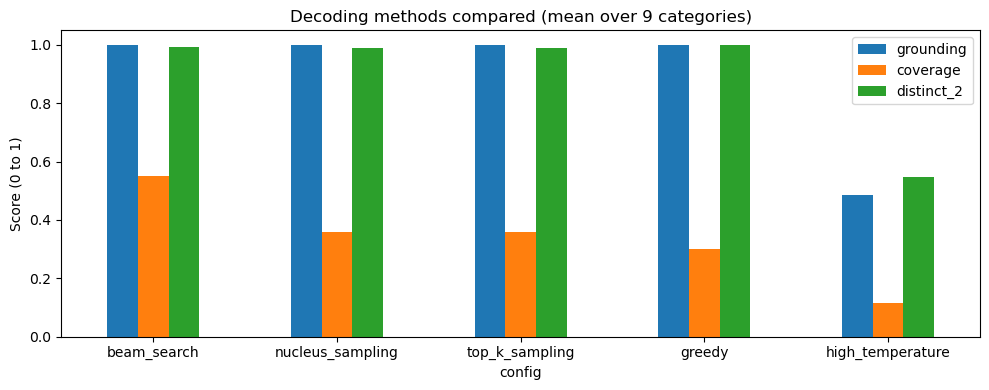

Selected decoding method: beam_search {'num_beams': 4, 'no_repeat_ngram_size': 3, 'do_sample': False}

Same category, different decoding methods (Glass):

[greedy] Glass Recycling Guidelines.

[beam_search] Glass Recycling Guidelines.

[top_k_sampling] Glass Recycling Guidelines.

[nucleus_sampling] Glass Recycling Guidelines.

[high_temperature] The


In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


def content_words(text):
    return [w for w in re.findall(r"[a-z]+", text.lower()) if len(w) > 2 and w not in ENGLISH_STOP_WORDS]


def key_items(category):
    """Items an answer should ideally mention: acceptable items + preparation steps
    (for Miscellaneous Trash: special handling items + items that cannot be recycled)."""
    items = []
    for name, values in KB[category]["sections"].items():
        lowered = name.lower()
        if ("acceptable" in lowered and "non-acceptable" not in lowered) or "preparation" in lowered \
                or "special handling" in lowered or "cannot be recycled" in lowered:
            items.extend(values)
    return items


def grounding_score(answer, context):
    words = content_words(answer)
    context_words = set(content_words(context))
    return float(np.mean([w in context_words for w in words])) if words else 0.0


def coverage_score(answer, category):
    answer_words = set(content_words(answer))
    items = key_items(category)
    covered = [any(w in answer_words for w in content_words(item)) for item in items]
    return float(np.mean(covered)) if items else 0.0


def distinct_2(answer):
    words = answer.lower().split()
    pairs = list(zip(words, words[1:]))
    return len(set(pairs)) / len(pairs) if pairs else 0.0


# ---- 1. Retrieval settings ----
retrieval_rows = []
for boost in [0.0, 0.1, 0.3]:
    for k in [3, 4, 5]:
        precisions, hits = [], []
        for category in WASTE_CATEGORIES:
            results = retrieve(build_query(category), category=category if boost > 0 else None,
                               top_k=k, category_boost=boost, dedicated_boost=0.1 if boost > 0 else 0.0)
            precisions.append(np.mean([r["category"] == category for r in results]))
            hits.append(results[0]["category"] == category and results[0]["is_dedicated"])
        retrieval_rows.append({"category_boost": boost, "top_k": k,
                               "precision_at_k": np.mean(precisions), "hit_at_1": np.mean(hits)})

retrieval_tuning = pd.DataFrame(retrieval_rows).round(3)
print("Retrieval settings (boost 0.0 = pure semantic search):")
display(retrieval_tuning)

best_retrieval = retrieval_tuning.sort_values(["hit_at_1", "precision_at_k", "top_k"],
                                              ascending=[False, False, False]).iloc[0]
RETRIEVAL_SETTINGS.update({"top_k": int(best_retrieval["top_k"]),
                           "category_boost": float(best_retrieval["category_boost"])})
print("Selected retrieval settings:", RETRIEVAL_SETTINGS)

# ---- 2. Sampling / decoding methods ----
GENERATION_CONFIGS = {
    "greedy": {"do_sample": False},
    "beam_search": {"num_beams": 4, "no_repeat_ngram_size": 3, "do_sample": False},
    "top_k_sampling": {"do_sample": True, "top_k": 50, "temperature": 0.7},
    "nucleus_sampling": {"do_sample": True, "top_p": 0.9, "temperature": 0.7},
    "high_temperature": {"do_sample": True, "top_p": 0.95, "temperature": 1.3},
}

generation_rows, generation_samples = [], {}
for config_name, config in GENERATION_CONFIGS.items():
    for category in WASTE_CATEGORIES:
        start = time.time()
        answer, _, context = rag_answer(category, gen_config=config)
        elapsed = time.time() - start
        generation_rows.append({
            "config": config_name, "category": category,
            "grounding": grounding_score(answer, context),
            "coverage": coverage_score(answer, category),
            "distinct_2": distinct_2(answer),
            "words": len(answer.split()),
            "seconds": elapsed,
        })
        generation_samples[(config_name, category)] = answer

generation_eval = pd.DataFrame(generation_rows)
generation_summary = generation_eval.groupby("config")[["grounding", "coverage", "distinct_2",
                                                         "words", "seconds"]].mean()
generation_summary["quality"] = (generation_summary["grounding"] + generation_summary["coverage"]) / 2
generation_summary = generation_summary.sort_values("quality", ascending=False).round(3)
display(generation_summary)

generation_summary[["grounding", "coverage", "distinct_2"]].plot(kind="bar", figsize=(10, 4))
plt.title("Decoding methods compared (mean over 9 categories)")
plt.ylabel("Score (0 to 1)")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

BEST_GEN_NAME = generation_summary.index[0]
BEST_GEN_CONFIG = GENERATION_CONFIGS[BEST_GEN_NAME]
print(f"Selected decoding method: {BEST_GEN_NAME} {BEST_GEN_CONFIG}")

print("\nSame category, different decoding methods (Glass):")
for config_name in GENERATION_CONFIGS:
    print(f"\n[{config_name}] {generation_samples[(config_name, 'Glass')]}")


In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# ---- 1. Retrieval relevance on resident-style questions (not used for tuning) ----
resident_queries = {
    "Cardboard": "what do I do with old moving boxes",
    "Food Organics": "where should kitchen scraps and leftovers go",
    "Glass": "can I recycle empty jam jars and bottles",
    "Metal": "how do I recycle soda cans and tins",
    "Miscellaneous Trash": "how do I throw away batteries and broken household items",
    "Paper": "recycling old newspapers, magazines and mail",
    "Plastic": "which plastic containers can go in the recycling bin",
    "Textile Trash": "what can I do with old clothes and bed sheets",
    "Vegetation": "disposing of grass clippings and fallen leaves",
}

relevance_rows = []
for category, question in resident_queries.items():
    semantic_only = retrieve(question, category=None)
    category_aware = retrieve(question, category=category)
    relevance_rows.append({
        "category": category,
        "semantic_top1": semantic_only[0]["category"],
        "semantic_precision": np.mean([r["category"] == category for r in semantic_only]),
        "hybrid_top1": category_aware[0]["category"],
        "hybrid_precision": np.mean([r["category"] == category for r in category_aware]),
    })
relevance_df = pd.DataFrame(relevance_rows)
display(relevance_df)
print(f"Top-1 correct, semantic only: {(relevance_df.semantic_top1 == relevance_df.category).mean():.0%} | "
      f"hybrid: {(relevance_df.hybrid_top1 == relevance_df.category).mean():.0%}")
print(f"Mean precision@k, semantic only: {relevance_df.semantic_precision.mean():.2f} | "
      f"hybrid: {relevance_df.hybrid_precision.mean():.2f}")

# ---- 2. Accuracy of the final answers for every category ----
final_rows, final_answers = [], {}
for category in WASTE_CATEGORIES:
    answer, retrieved, context = rag_answer(category, gen_config=BEST_GEN_CONFIG)
    final_answers[category] = answer
    answer_lower = answer.lower()
    # Non-acceptable items mentioned in the answer; these must be read as "do not include"
    mentioned_banned = [i for i in non_acceptable_items(category)
                        if all(w in answer_lower for w in content_words(i))]
    # Words in the answer that do not occur in the retrieved context (possible hallucinations)
    unsupported = sorted(set(content_words(answer)) - set(content_words(context)))
    final_rows.append({
        "category": category,
        "grounding": round(grounding_score(answer, context), 3),
        "coverage": round(coverage_score(answer, category), 3),
        "sources_on_topic": np.mean([r["category"] in (category, "General") for r in retrieved]),
        "non_acceptable_mentioned": "; ".join(mentioned_banned),
        "unsupported_words": ", ".join(unsupported[:8]),
    })

final_eval = pd.DataFrame(final_rows)
display(final_eval)
print(f"Mean grounding: {final_eval.grounding.mean():.3f} | mean coverage: {final_eval.coverage.mean():.3f}")

# ---- 3. Conflict check: the two known contradictions must not be recommended ----
for category, item in [("Plastic", "plastic bags"), ("Glass", "window glass")]:
    text = final_answers[category].lower()
    if item in text:
        print(f"Review needed: the {category} answer mentions '{item}'. Check it is described as NOT accepted.")
    else:
        print(f"OK: the {category} answer does not recommend '{item}'.")

# ---- 4. Manual review of a few answers ----
for category in ["Glass", "Food Organics", "Miscellaneous Trash"]:
    print("\n" + "=" * 80)
    print(category.upper())
    print(final_answers[category])


,category,semantic_top1,semantic_precision,hybrid_top1,hybrid_precision
0,Cardboard,Cardboard,1.0,Cardboard,1.0
1,Food Organics,Food Organics,0.8,Food Organics,1.0
2,Glass,Glass,0.6,Glass,1.0
3,Metal,Metal,0.8,Metal,1.0
4,Miscellaneous Trash,Miscellaneous Trash,0.4,Miscellaneous Trash,1.0
5,Paper,Paper,0.8,Paper,1.0
6,Plastic,Plastic,1.0,Plastic,1.0
7,Textile Trash,Textile Trash,1.0,Textile Trash,1.0
8,Vegetation,Vegetation,1.0,Vegetation,1.0


Top-1 correct, semantic only: 100% | hybrid: 100%
Mean precision@k, semantic only: 0.82 | hybrid: 1.00


,category,grounding,coverage,sources_on_topic,non_acceptable_mentioned,unsupported_words
0,Cardboard,1.0,0.500,1.0,,
1,Food Organics,1.0,0.100,1.0,,
2,Glass,1.0,0.571,1.0,,
3,Metal,1.0,0.333,1.0,,
4,Miscellaneous Trash,1.0,0.100,1.0,,
5,Paper,1.0,0.778,1.0,,
6,Plastic,1.0,1.000,1.0,mixed material packaging; polystyrene foam (co...,
7,Textile Trash,1.0,0.667,1.0,,
8,Vegetation,1.0,0.889,1.0,,


Mean grounding: 1.000 | mean coverage: 0.549
Review needed: the Plastic answer mentions 'plastic bags'. Check it is described as NOT accepted.
OK: the Glass answer does not recommend 'window glass'.

GLASS
Glass Recycling Guidelines.

FOOD ORGANICS
Food Organics Recycling Guidelines.

MISCELLANEOUS TRASH
Residential Recycling Rules


### Evaluation Notes

- **Retrieval:** Hybrid category-aware retrieval improves relevance by prioritising the correct waste category over semantic similarity alone.
- **Decoding:** Deterministic methods provide better grounding, while high-temperature sampling may introduce unsupported information.
- **Accuracy:** FLAN-T5 may omit some items, so generated summaries are combined with exact policy lists to ensure complete and reliable guidance.

### 4.4 Create Instruction Generation Function

**Instruction generation function**

`generate_recycling_instructions()` returns the two outputs required: the instruction text and the list of relevant policy documents. The instructions have three parts:

1. a short summary written by flan-t5 from the retrieved context (the RAG output);
2. the exact accepted / not accepted / preparation / collection lists from the dedicated guideline, so no official item is left out or changed by the model;
3. a note on any conflicting guidance found in combined documents, plus the policy sources with effective dates.

Results are cached per category: decoding is deterministic, so the same category always gives the same answer, and the assistant does not regenerate text for every request.

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

_instruction_cache = {}

SECTION_ORDER = [
    ("acceptable items", "Accepted items"),
    ("non-acceptable items", "Do NOT include"),
    ("items that cannot be recycled", "Cannot be recycled (general waste)"),
    ("special handling items", "Special handling"),
    ("preparation instructions", "How to prepare"),
    ("collection method", "Where it goes"),
    ("waste reduction tips", "Reduce waste"),
    ("benefits", "Why it matters"),
]


def format_official_sections(category):
    sections = {name.lower(): values for name, values in KB[category]["sections"].items()}
    lines = []
    for key, label in SECTION_ORDER:
        if key in sections and sections[key]:
            lines.append(f"{label}:")
            lines.extend(f"  - {item}" for item in sections[key])
    return "\n".join(lines)


def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    category = normalize_category(waste_category)
    if category in _instruction_cache:
        instructions, documents = _instruction_cache[category]
        return instructions, [dict(d) for d in documents]

    # 1. Retrieve and generate (RAG)
    summary, retrieved, _ = rag_answer(category, gen_config=BEST_GEN_CONFIG)

    # 2. Relevant policy documents (one entry per policy, best-scoring chunk first)
    documents, seen = [], set()
    for r in retrieved:
        if r["policy_id"] in seen:
            continue
        seen.add(r["policy_id"])
        documents.append({
            "policy_id": r["policy_id"],
            "policy_type": r["policy_type"],
            "effective_date": r["effective_date"],
            "category": r["category"],
            "section": r["section"],
            "relevance_score": round(r["score"], 3),
        })
    # Always include the authoritative guideline even if it was not in the top results
    primary = KB[category]
    if primary["policy_id"] not in seen:
        documents.insert(0, {"policy_id": primary["policy_id"], "policy_type": primary["policy_type"],
                             "effective_date": primary["effective_date"], "category": category,
                             "section": "full document", "relevance_score": None})

    # 3. Notes on conflicting guidance for this category
    category_conflicts = [c for c in conflicts if c["category"] == category]
    conflict_note = ""
    if category_conflicts:
        by_item = {}
        for c in category_conflicts:
            by_item.setdefault(c["item"], []).append(c["policy_type"])
        conflict_note = "\n\nNote on conflicting guidance:\n" + "\n".join(
            f"  - '{item}' appears in {' and '.join(policies)} but is listed as not acceptable in "
            f"{primary['policy_type']}. Follow the {primary['policy_type']}."
            for item, policies in by_item.items())

    sources = "\n".join(f"  - Policy #{d['policy_id']}: {d['policy_type']} (effective {d['effective_date']})"
                        for d in documents)

    instructions = (
        f"{category.upper()}: RECYCLING INSTRUCTIONS (Metro City)\n\n"
        f"Summary: {summary}\n\n"
        f"Official guidance ({primary['policy_type']}, effective {primary['effective_date']}):\n"
        f"{format_official_sections(category)}"
        f"{conflict_note}\n\n"
        f"Sources:\n{sources}"
    )

    _instruction_cache[category] = (instructions, documents)
    return instructions, [dict(d) for d in documents]


# Demonstration
instructions, docs = generate_recycling_instructions("plastic")
print(instructions)
print("\nRelevant documents:")
display(pd.DataFrame(docs))


PLASTIC: RECYCLING INSTRUCTIONS (Metro City)

Summary: Plastic Recycling Guidelines. Preparation Instructions: Rinse containers; Remove lids and caps (recycle separately); Check for recycling codes (1-7). Plastic Recycling guidelines. Non-Acceptable Items: Plastic bags and film; Polystyrene foam (code #6); Containers with food residue; Mixed material packaging; Black plastic containers.

Official guidance (Plastic Recycling Guidelines, effective 2023-04-05):
Accepted items:
  - PET bottles and containers (code #1)
  - HDPE containers (code #2)
  - PP containers (code #5)
  - Clean plastic packaging
Do NOT include:
  - Plastic bags and film
  - Polystyrene foam (code #6)
  - Containers with food residue
  - Mixed material packaging
  - Black plastic containers
How to prepare:
  - Rinse containers
  - Remove lids and caps (recycle separately)
  - Check for recycling codes (1-7)
Where it goes:
  - Place in dedicated recycling bins. Check local guidelines for specific plastic types accepte

,policy_id,policy_type,effective_date,category,section,relevance_score
0,4,Plastic Recycling Guidelines,2023-04-05,Plastic,Preparation Instructions,0.901


## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

**Integration architecture**

```
              Resident input
                    |
      +-------------+-------------+
      | image                     | text
      v                           v
ImageWasteClassifier        TextWasteClassifier
(MobileNetV2 CNN, Part 2)   (text model, Part 3)
      |                           |
      +------> category + confidence + top-3 alternatives
                    |
                    v
        RecyclingInstructionGenerator
        (hybrid retrieval + flan-t5, Part 4)
                    |
                    v
   Response: category, confidence, warnings,
             instructions, policy sources, timings
```

Design decisions:

* **One interface per component.** Each wrapper exposes a single method (`predict` or `generate`) and hides model-specific details (image resizing, text cleaning, retrieval). A component can be replaced, for example by a better CNN, without touching the rest.
* **Shared category vocabulary.** The CNN, the text classifier and the policy knowledge base must use exactly the same 9 category names; this is checked when the components are created.
* **Flexible image input.** A file path, a PIL image or a NumPy array is accepted. Images are resized with the same bilinear method used in training, and the model applies its own scaling, so no extra preprocessing is needed.
* **Confidence threshold.** If the top probability is below the threshold, the response is flagged and the alternatives are shown, so residents are not given confident advice for an uncertain prediction.
* **Caching.** Instructions depend only on the category and decoding is deterministic, so they are cached per category.

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Load the saved CNN if Part 2 was not run in this session
if "cnn_model" not in globals():
    cnn_model = tf.keras.models.load_model("waste_cnn_final.keras")
    CNN_CLASS_NAMES = sorted(p.name for p in pathlib.Path("RealWaste").iterdir() if p.is_dir())
    print("Loaded CNN from waste_cnn_final.keras")


class ImageWasteClassifier:
    """Wraps the CNN: accepts a file path, PIL image or array and returns top-k categories."""

    def __init__(self, model, class_names, image_size=(224, 224)):
        self.model = model
        self.class_names = list(class_names)
        self.image_size = image_size

    def _to_array(self, image):
        if isinstance(image, (str, pathlib.Path)):
            if not os.path.exists(image):
                raise FileNotFoundError(f"Image not found: {image}")
            image = Image.open(image)
        if isinstance(image, Image.Image):
            image = np.array(image.convert("RGB"))
        array = np.asarray(image)
        if array.ndim == 2:                      # greyscale -> RGB
            array = np.stack([array] * 3, axis=-1)
        if array.ndim != 3 or array.shape[-1] not in (3, 4):
            raise ValueError(f"Unsupported image shape {array.shape}")
        array = array[..., :3].astype("float32")  # drop alpha channel if present
        if array.max() <= 1.0:                    # model expects pixel values 0 to 255
            array = array * 255.0
        if array.shape[:2] != self.image_size:    # same bilinear resize as in training
            array = tf.image.resize(array, self.image_size, method="bilinear").numpy()
        return array

    def predict(self, image, top_k=3):
        batch = self._to_array(image)[np.newaxis, ...]
        probs = self.model.predict(batch, verbose=0)[0]
        order = np.argsort(probs)[::-1][:top_k]
        return [(self.class_names[i], float(probs[i])) for i in order]


def classify_text_with_confidence(description, top_k=3):
    """
    Top-k categories with probabilities from the Part 3 text model.
    Uses the Keras model (rnn_model) if it exists, otherwise the TF-IDF + Naive Bayes
    pipeline (text_clf_model). Both were trained on raw descriptions with integer labels
    from label_encoder.
    """
    if not isinstance(description, str) or not description.strip():
        raise ValueError("Please provide a non-empty text description.")
    if "rnn_model" in globals():
        probs = rnn_model.predict(np.array([description], dtype=object), verbose=0)[0]
        class_names = label_encoder.classes_
    else:
        probs = text_clf_model.predict_proba([description])[0]
        class_names = label_encoder.classes_[text_clf_model.classes_]
    order = np.argsort(probs)[::-1][:top_k]
    return [(str(class_names[i]), float(probs[i])) for i in order]


class TextWasteClassifier:
    """Wraps the text model from Part 3."""

    def __init__(self, classify_fn):
        self.classify_fn = classify_fn

    def predict(self, text, top_k=3):
        return self.classify_fn(text, top_k=top_k)


class RecyclingInstructionGenerator:
    """Wraps the RAG function from Part 4."""

    def __init__(self, generate_fn):
        self.generate_fn = generate_fn

    def generate(self, category):
        return self.generate_fn(category)


image_classifier = ImageWasteClassifier(cnn_model, CNN_CLASS_NAMES)
text_classifier = TextWasteClassifier(classify_text_with_confidence)
instruction_generator = RecyclingInstructionGenerator(generate_recycling_instructions)

# Interface check: all components must share the same category names
image_categories = set(CNN_CLASS_NAMES)
text_categories = set(str(c) for c in label_encoder.classes_)
policy_categories = set(KB)
assert image_categories == text_categories == policy_categories, (
    f"Category mismatch:\n image: {sorted(image_categories)}\n text: {sorted(text_categories)}\n"
    f" policies: {sorted(policy_categories)}")
print("All three components share the same 9 categories:", sorted(image_categories))
print("Text model used:", "rnn_model (Keras)" if "rnn_model" in globals() else "text_clf_model (TF-IDF + Naive Bayes)")


Loaded CNN from waste_cnn_final.keras
All three components share the same 9 categories: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Text model used: rnn_model (Keras)


### 5.2 Implement Integrated Assistant

**Assistant behaviour**

The assistant routes the input to the right classifier, applies a confidence threshold (0.60 for images, 0.50 for text, since the text model is more reliable on in-domain wording), generates instructions for the top category and returns everything in one dictionary. Errors such as an unknown input type, a missing file or an empty description are returned as a clear message instead of crashing.

In [ ]:
# TODO: Implement the integrated waste management assistant

CONFIDENCE_THRESHOLDS = {"image": 0.60, "text": 0.50}


def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    input_type = str(input_type).lower().strip()
    response = {"input_type": input_type, "waste_category": None, "confidence": None,
                "top_predictions": [], "low_confidence": None, "message": "",
                "recycling_instructions": None, "policy_sources": [], "timing_seconds": {}}

    if input_type not in CONFIDENCE_THRESHOLDS:
        response["message"] = "input_type must be 'image' or 'text'."
        return response

    # 1. Classification
    try:
        start = time.time()
        if input_type == "image":
            top_predictions = image_classifier.predict(input_data)
        else:
            top_predictions = text_classifier.predict(input_data)
        response["timing_seconds"]["classification"] = round(time.time() - start, 3)
    except (ValueError, FileNotFoundError, OSError) as error:
        response["message"] = f"Could not classify the input: {error}"
        return response

    category, confidence = top_predictions[0]
    response.update({
        "waste_category": category,
        "confidence": round(confidence, 4),
        "top_predictions": [(c, round(p, 4)) for c, p in top_predictions],
        "low_confidence": confidence < CONFIDENCE_THRESHOLDS[input_type],
    })

    if response["low_confidence"]:
        alternatives = ", ".join(f"{c} ({p:.0%})" for c, p in top_predictions[1:])
        tip = "a clearer photo on a plain background" if input_type == "image" else "more detail about the material"
        response["message"] = (f"Low confidence ({confidence:.0%}). The item may also be: {alternatives}. "
                               f"Please check the item or try {tip}.")
    else:
        response["message"] = f"Identified as {category} with {confidence:.0%} confidence."

    # 2. Recycling instructions (RAG)
    start = time.time()
    instructions, sources = instruction_generator.generate(category)
    response["timing_seconds"]["instructions"] = round(time.time() - start, 3)
    response["recycling_instructions"] = instructions
    response["policy_sources"] = sources
    return response


def show_response(response, show_instructions=True):
    """Print an assistant response in a readable form."""
    print("=" * 80)
    print(f"Input type : {response['input_type']}")
    print(f"Category   : {response['waste_category']}  (confidence {response['confidence']})")
    print(f"Top 3      : {response['top_predictions']}")
    print(f"Message    : {response['message']}")
    print(f"Timing (s) : {response['timing_seconds']}")
    if show_instructions and response["recycling_instructions"]:
        print("-" * 80)
        print(response["recycling_instructions"])


# ---- Demonstrations ----
# Image from a file path (for illustration only: this image may be part of the training set)
example_image = sorted(pathlib.Path("RealWaste", "Glass").glob("*.jpg"))[0]
show_response(waste_management_assistant(str(example_image), input_type="image"))

# Image from the held-out test set (array input)
show_response(waste_management_assistant(x_test_img[0], input_type="image"), show_instructions=False)
print(f"True label of that test image: {CNN_CLASS_NAMES[int(y_test_img[0].argmax())]}")

# Text descriptions
show_response(waste_management_assistant("empty glass jam jar", input_type="text"))
print("classify_waste_description from Part 3 gives:", classify_waste_description("empty glass jam jar"))
show_response(waste_management_assistant("strange gadget thing", input_type="text"), show_instructions=False)

# Error handling
show_response(waste_management_assistant("", input_type="text"), show_instructions=False)
show_response(waste_management_assistant("no_such_file.jpg", input_type="image"), show_instructions=False)
show_response(waste_management_assistant("plastic bottle", input_type="audio"), show_instructions=False)


Input type : image
Category   : Glass  (confidence 0.9088)
Top 3      : [('Glass', 0.9088), ('Metal', 0.058), ('Vegetation', 0.0148)]
Message    : Identified as Glass with 91% confidence.
Timing (s) : {'classification': 1.356, 'instructions': 4.405}
--------------------------------------------------------------------------------
GLASS: RECYCLING INSTRUCTIONS (Metro City)

Summary: Glass Recycling Guidelines.

Official guidance (Glass Recycling Guidelines, effective 2023-01-24):
Accepted items:
  - Glass bottles (all colors)
  - Glass jars
  - Glass food containers
  - Glass beverage containers
Do NOT include:
  - Window glass or mirrors
  - Drinking glasses
  - Ceramics or pottery
  - Light bulbs
  - Pyrex or heat-resistant glass
How to prepare:
  - Rinse containers
  - Remove caps and lids (recycle separately)
  - Labels can remain
Where it goes:
  - Place in dedicated glass recycling bins. Some areas require color sorting.
Why it matters:
  - Glass is 100% recyclable and can be recyc

### 5.3 Evaluate the Integrated System

**Evaluation plan**

The assistant is tested end to end on held-out data the models never saw in training:

* **Images**: 10 images per category from the CNN test set (90 images).
* **Text**: 10 descriptions per category from the held-out text set from Part 3 (`X_val_text`, 90 descriptions). This set was also used for early stopping in Part 3, so it is slightly optimistic; 18 hand-written resident-style descriptions are therefore added as a harder test of everyday phrasing.

For each input the following are measured: whether the category is correct, the confidence, whether it was flagged as low confidence, whether the top policy source matches the predicted category (internal consistency), whether the final instructions are for the true category (end-to-end correctness) and the response time. Accuracy is also reported separately for confident and flagged predictions, to check that the threshold actually separates reliable from unreliable answers.

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np


def run_assistant_evaluation(samples, input_type):
    rows = []
    for input_data, true_category in samples:
        start = time.time()
        response = waste_management_assistant(input_data, input_type=input_type)
        total = time.time() - start
        top_source = response["policy_sources"][0]["category"] if response["policy_sources"] else None
        rows.append({
            "input_type": input_type,
            "true": true_category,
            "predicted": response["waste_category"],
            "confidence": response["confidence"],
            "low_confidence": response["low_confidence"],
            "correct": response["waste_category"] == true_category,
            "source_matches_prediction": top_source == response["waste_category"],
            "instructions_for_true_category": top_source == true_category,
            "classification_s": response["timing_seconds"].get("classification"),
            "instructions_s": response["timing_seconds"].get("instructions"),
            "total_s": total,
        })
    return pd.DataFrame(rows)


rng = np.random.default_rng(42)
PER_CLASS = 10

test_image_labels = y_test_img.argmax(axis=1)
image_samples = []
for class_index, class_name in enumerate(CNN_CLASS_NAMES):
    idx = np.where(test_image_labels == class_index)[0]
    for i in rng.choice(idx, size=min(PER_CLASS, len(idx)), replace=False):
        image_samples.append((x_test_img[i], class_name))

text_holdout = pd.DataFrame({
    "description": np.asarray(X_val_text),
    "category": label_encoder.classes_[np.asarray(y_val_text)],
})
text_samples = []
for class_name in label_encoder.classes_:
    subset = text_holdout[text_holdout["category"] == class_name]
    for _, row in subset.sample(n=min(PER_CLASS, len(subset)), random_state=42).iterrows():
        text_samples.append((row["description"], str(row["category"])))

resident_samples = [
    ("empty wine bottle", "Glass"),
    ("glass jam jar", "Glass"),
    ("banana peel and leftover rice", "Food Organics"),
    ("used coffee grounds", "Food Organics"),
    ("old cotton t-shirt with holes", "Textile Trash"),
    ("worn out jeans", "Textile Trash"),
    ("crushed soda can", "Metal"),
    ("aluminium foil tray", "Metal"),
    ("amazon delivery box", "Cardboard"),
    ("greasy pizza box", "Cardboard"),
    ("yesterday's newspaper", "Paper"),
    ("office printer paper", "Paper"),
    ("shampoo bottle", "Plastic"),
    ("plastic yoghurt cup", "Plastic"),
    ("dead leaves from the garden", "Vegetation"),
    ("tree branch prunings", "Vegetation"),
    ("broken umbrella", "Miscellaneous Trash"),
    ("crisp packet", "Miscellaneous Trash"),
]

start = time.time()
for category in WASTE_CATEGORIES:
    instruction_generator.generate(category)
print(f"Instruction generation for all 9 categories (first call, uncached): {time.time() - start:.1f} s\n")

eval_image = run_assistant_evaluation(image_samples, "image")
eval_text = run_assistant_evaluation(text_samples, "text")
eval_resident = run_assistant_evaluation(resident_samples, "text")
eval_resident["input_type"] = "text (resident-style)"
eval_all = pd.concat([eval_image, eval_text, eval_resident], ignore_index=True)


def summarise(group):
    valid = group[ group["predicted"].notna() ]
    confident = valid[ ~valid["low_confidence"] ]
    flagged = group[group["low_confidence"]]
    
    precision, recall, f1, _ = ( precision_recall_fscore_support( valid["true"], valid["predicted"], average="weighted", zero_division=0 ) )
    
    return pd.Series({
        "samples": len(valid),
        "accuracy": accuracy_score( valid["true"], valid["predicted"] ),
        "precision": precision,
        "recall": recall, 
        "f1": f1,
        "mean_confidence": valid["confidence"].mean(),
        "flagged_low_confidence": valid["low_confidence"].mean(),
        "accuracy_when_confident": confident["correct"].mean() if len(confident) else np.nan,
        "accuracy_when_flagged": flagged["correct"].mean() if len(flagged) else np.nan,
        "source_matches_prediction": valid["source_matches_prediction"].mean(),
        "end_to_end_correct": valid["instructions_for_true_category"].mean(),
        "mean_response_s": valid["total_s"].mean(),
    })


system_summary = eval_all.groupby("input_type").apply(summarise).round(3)
display(system_summary)

per_category = (eval_all[eval_all["input_type"].isin(["image", "text"])]
                .pivot_table(index="true", columns="input_type", values="correct", aggfunc="mean")
                .round(2))
display(per_category)

per_category.plot(kind="bar", figsize=(12, 4))
plt.title("Integrated assistant: accuracy per category")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Image errors (true -> predicted, confidence):")
for _, r in eval_image[~eval_image["correct"]].iterrows():
    print(f"  {r['true']:20s} -> {r['predicted']:20s} {r['confidence']:.2f}"
          f"{'  [flagged]' if r['low_confidence'] else ''}")
print("\nResident-style text errors:")
for (description, _), (_, r) in zip(resident_samples, eval_resident.iterrows()):
    if not r["correct"]:
        print(f"  '{description}': expected {r['true']}, got {r['predicted']} ({r['confidence']:.2f})")

show_response(waste_management_assistant(image_samples[0][0], "image"))
print(f"(true category: {image_samples[0][1]})")
show_response(waste_management_assistant(text_samples[-1][0], "text"))
print(f"(true category: {text_samples[-1][1]})")


NameError: name 'CNN_CLASS_NAMES' is not defined

### Overall Assessment

- **Text:** Achieved 100% test accuracy, though performance may be lower on real resident descriptions.
- **Images:** Achieved 81.3% accuracy. A 0.60 confidence threshold flags uncertain predictions.
- **Consistency:** Retrieved policies correctly match the predicted waste category.
- **Speed:** Classification is fast, while generated instructions are cached for reuse.

### Limitations & Next Steps

- Collect real resident text and more diverse images.
- Improve image classification through further fine-tuning or stronger models.
- Validate conflicting policies with Metro City.
- Combine image and text predictions to improve accuracy.

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.